Introduction to the Project on Food Waste and Malnutrition Analysis

The phenomenon of food waste represents one of the most important challenges of our time, as it negatively impacts both the environment and the economic and social balance of communities. This project aims to analyze food waste in different countries around the world, exploring how it is related to socioeconomic factors such as Gross National Income (GNI), agricultural production, and malnutrition conditions.

The goal is to understand whether significant differences exist between countries with high per capita income and those with lower income, while simultaneously assessing the level of food waste and the situation of malnutrition, particularly among children. Using datasets from international sources such as the FAO, the Global Hunger Index (GHI), and other human development indicators, the project will explore how food production, access to resources, and economic disparities contribute to creating a world where a significant portion of food is wasted while another part of the population suffers from hunger and malnutrition.

Through data analysis and the visualization of correlations, we hope to identify areas of intervention where policies and practices can be improved to reduce both food waste and the level of global food insecurity. This project will not only offer a quantitative view of the issues but will also shed light on the relationships and disparities that require concrete actions to make the food system more sustainable and equitable for all.

PROJECT STRUCTURE

1. Data Loading
2. Preprocessing
3. EDA (Exploratory Data Analysis)
4. Application of ML Algorithms (XGBoost and Random Forest)
5. Conclusions and Recommendations

1. DATA LOADING

In [9]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, r2_score, mean_absolute_error
import xgboost as xgb
import seaborn as sns
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV



In [10]:
# Caricamento dei dataset
dataset_FAO = r'C:\Users\alessandro\Desktop\desktop\workspace\PROGETTI PHYTON\datset\analisi alimentare\FAO.csv'
dataset_Waste = r'C:\Users\alessandro\Desktop\desktop\workspace\PROGETTI PHYTON\datset\analisi alimentare\Food Waste data and research - by country.csv'
dataset_food_production = r'C:\Users\alessandro\Desktop\desktop\workspace\PROGETTI PHYTON\datset\analisi alimentare\Food_Production_inpat.csv'
dataset_GHI = r'C:\Users\alessandro\Desktop\desktop\workspace\PROGETTI PHYTON\datset\analisi alimentare\global-hunger-index.csv'
dataset_GNI = r'C:\Users\alessandro\Desktop\desktop\workspace\PROGETTI PHYTON\datset\analisi alimentare\gross-national-income-per-capita.csv'
dataset_human_development = r'C:\Users\alessandro\Desktop\desktop\workspace\PROGETTI PHYTON\datset\analisi alimentare\human-development-index.csv' 
dataset_meat_consumption = r'C:\Users\alessandro\Desktop\desktop\workspace\PROGETTI PHYTON\datset\analisi alimentare\meat_consumption_worldwide.csv'
dataset_children_under_weight = r'C:\Users\alessandro\Desktop\desktop\workspace\PROGETTI PHYTON\datset\analisi alimentare\share-of-children-underweight.csv'
dataset_world_food_production = r'C:\Users\alessandro\Desktop\desktop\workspace\PROGETTI PHYTON\datset\analisi alimentare\world food production.csv'

In [11]:
# Caricamento dei dati in un dizionario
datasets = {
    'FAO': pd.read_csv(dataset_FAO, encoding='latin1'),
    'Food Waste': pd.read_csv(dataset_Waste, encoding='latin1'),
    'Food Production': pd.read_csv(dataset_food_production, encoding='latin1'),
    'Global Hunger Index': pd.read_csv(dataset_GHI, encoding='latin1'),
    'Gross National Income': pd.read_csv(dataset_GNI, encoding='latin1'),
    'Human Development Index': pd.read_csv(dataset_human_development, encoding='latin1'),  # Corretto il nome della variabile
    'Meat Consumption': pd.read_csv(dataset_meat_consumption, encoding='latin1'),
    'Children Under Weight': pd.read_csv(dataset_children_under_weight, encoding='latin1'),
     'World Food Production': pd.read_csv(dataset_world_food_production, encoding='latin1')
}

# Mostra le prime righe di ogni dataset 
for name, data in datasets.items():
    print(f"\nDataset: {name}")
    print(data.head())


Dataset: FAO
  Area Abbreviation  Area Code         Area  Item Code  \
0               AFG          2  Afghanistan       2511   
1               AFG          2  Afghanistan       2805   
2               AFG          2  Afghanistan       2513   
3               AFG          2  Afghanistan       2513   
4               AFG          2  Afghanistan       2514   

                       Item  Element Code Element         Unit  latitude  \
0        Wheat and products          5142    Food  1000 tonnes     33.94   
1  Rice (Milled Equivalent)          5142    Food  1000 tonnes     33.94   
2       Barley and products          5521    Feed  1000 tonnes     33.94   
3       Barley and products          5142    Food  1000 tonnes     33.94   
4        Maize and products          5521    Feed  1000 tonnes     33.94   

   longitude  ...   Y2004   Y2005   Y2006   Y2007   Y2008   Y2009   Y2010  \
0      67.71  ...  3249.0  3486.0  3704.0  4164.0  4252.0  4538.0  4605.0   
1      67.71  ...   419.0 

2. PREPROCESSING

Fao

In [12]:
# Direct access to the "FAO" dataset from the datasets dictionary
fao_data = datasets['FAO']

# Removal of unnecessary columns
columns_to_drop = ['Area Code', 'Item Code', 'Element Code', 'latitude', 'longitude']
fao_data_cleaned = fao_data.drop(columns=columns_to_drop)

# Displaying the first rows of the dataset after column removal
fao_data_cleaned.head()



,Area Abbreviation,Area,Item,Element,Unit,Y1961,Y1962,Y1963,Y1964,Y1965,...,Y2004,Y2005,Y2006,Y2007,Y2008,Y2009,Y2010,Y2011,Y2012,Y2013
0,AFG,Afghanistan,Wheat and products,Food,1000 tonnes,1928.0,1904.0,1666.0,1950.0,2001.0,...,3249.0,3486.0,3704.0,4164.0,4252.0,4538.0,4605.0,4711.0,4810,4895
1,AFG,Afghanistan,Rice (Milled Equivalent),Food,1000 tonnes,183.0,183.0,182.0,220.0,220.0,...,419.0,445.0,546.0,455.0,490.0,415.0,442.0,476.0,425,422
2,AFG,Afghanistan,Barley and products,Feed,1000 tonnes,76.0,76.0,76.0,76.0,76.0,...,58.0,236.0,262.0,263.0,230.0,379.0,315.0,203.0,367,360
3,AFG,Afghanistan,Barley and products,Food,1000 tonnes,237.0,237.0,237.0,238.0,238.0,...,185.0,43.0,44.0,48.0,62.0,55.0,60.0,72.0,78,89
4,AFG,Afghanistan,Maize and products,Feed,1000 tonnes,210.0,210.0,214.0,216.0,216.0,...,120.0,208.0,233.0,249.0,247.0,195.0,178.0,191.0,200,200


Food_waste

In [13]:
columns_to_drop_fw = ['M49 code', 'Source']
food_waste_data_cleaned = datasets['Food Waste'].drop(columns=columns_to_drop_fw)

print("\nFood Waste Data (Cleaned):")
print(food_waste_data_cleaned.head())



Food Waste Data (Cleaned):
       Country  combined figures (kg/capita/year)  \
0  Afghanistan                                126   
1      Albania                                127   
2      Algeria                                135   
3      Andorra                                123   
4       Angola                                144   

   Household estimate (kg/capita/year)  Household estimate (tonnes/year)  \
0                                   82                           3109153   
1                                   83                            238492   
2                                   91                           3918529   
3                                   84                              6497   
4                                  100                           3169523   

   Retail estimate (kg/capita/year)  Retail estimate (tonnes/year)  \
0                                16                         594982   
1                                16                     

Food production

In [14]:
dataset_food_production = datasets['Food Production']

# Replacing missing values with 'N/A'
food_production_data_cleaned = dataset_food_production.fillna('N/A')
print(food_production_data_cleaned.head())

          Food product  Land use change  Animal Feed  Farm  Processing  \
0  Wheat & Rye (Bread)              0.1          0.0   0.8         0.2   
1         Maize (Meal)              0.3          0.0   0.5         0.1   
2        Barley (Beer)              0.0          0.0   0.2         0.1   
3              Oatmeal              0.0          0.0   1.4         0.0   
4                 Rice              0.0          0.0   3.6         0.1   

   Transport  Packging  Retail  Total_emissions  \
0        0.1       0.1     0.1              1.4   
1        0.1       0.1     0.0              1.1   
2        0.0       0.5     0.3              1.1   
3        0.1       0.1     0.0              1.6   
4        0.1       0.1     0.1              4.0   

  Eutrophying emissions per 1000kcal (gPOâeq per 1000kcal)  ...  \
0                                                N/A          ...   
1                                                N/A          ...   
2                                        

Ghi

In [15]:
dataset_GHI = datasets['Global Hunger Index']

# Removing the '411773-annotations' column
ghi_data_cleaned = dataset_GHI.drop(columns=['411773-annotations'])

# Displaying the first rows of the dataset after removing the column
print(ghi_data_cleaned.head())


        Entity Code  Year  Global Hunger Index (2021)
0  Afghanistan  AFG  2000                        50.9
1  Afghanistan  AFG  2006                        42.7
2  Afghanistan  AFG  2012                        34.3
3  Afghanistan  AFG  2021                        28.3
4      Albania  ALB  2000                        20.7


The other datasets are clean and ready for analysis.

3. EDA

Fao

- Top 10 countries for food production

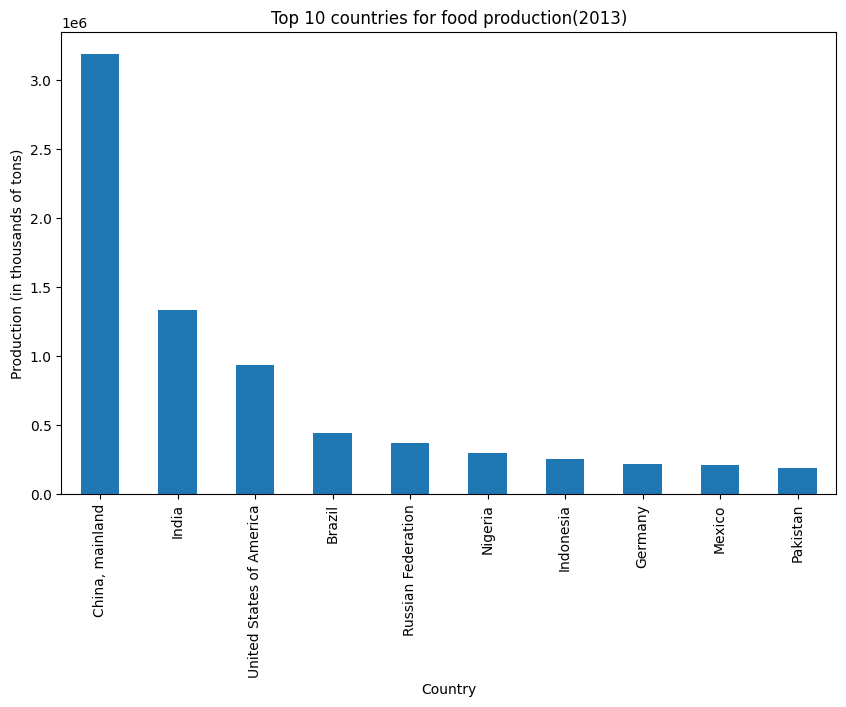

In [16]:
top_countries = fao_data_cleaned.groupby('Area')['Y2013'].sum().sort_values(ascending=False).head(10)
top_countries.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Country')
plt.ylabel('Production (in thousands of tons)')
plt.title('Top 10 countries for food production(2013)')
plt.show()

- Evolution of production over time for the top 10

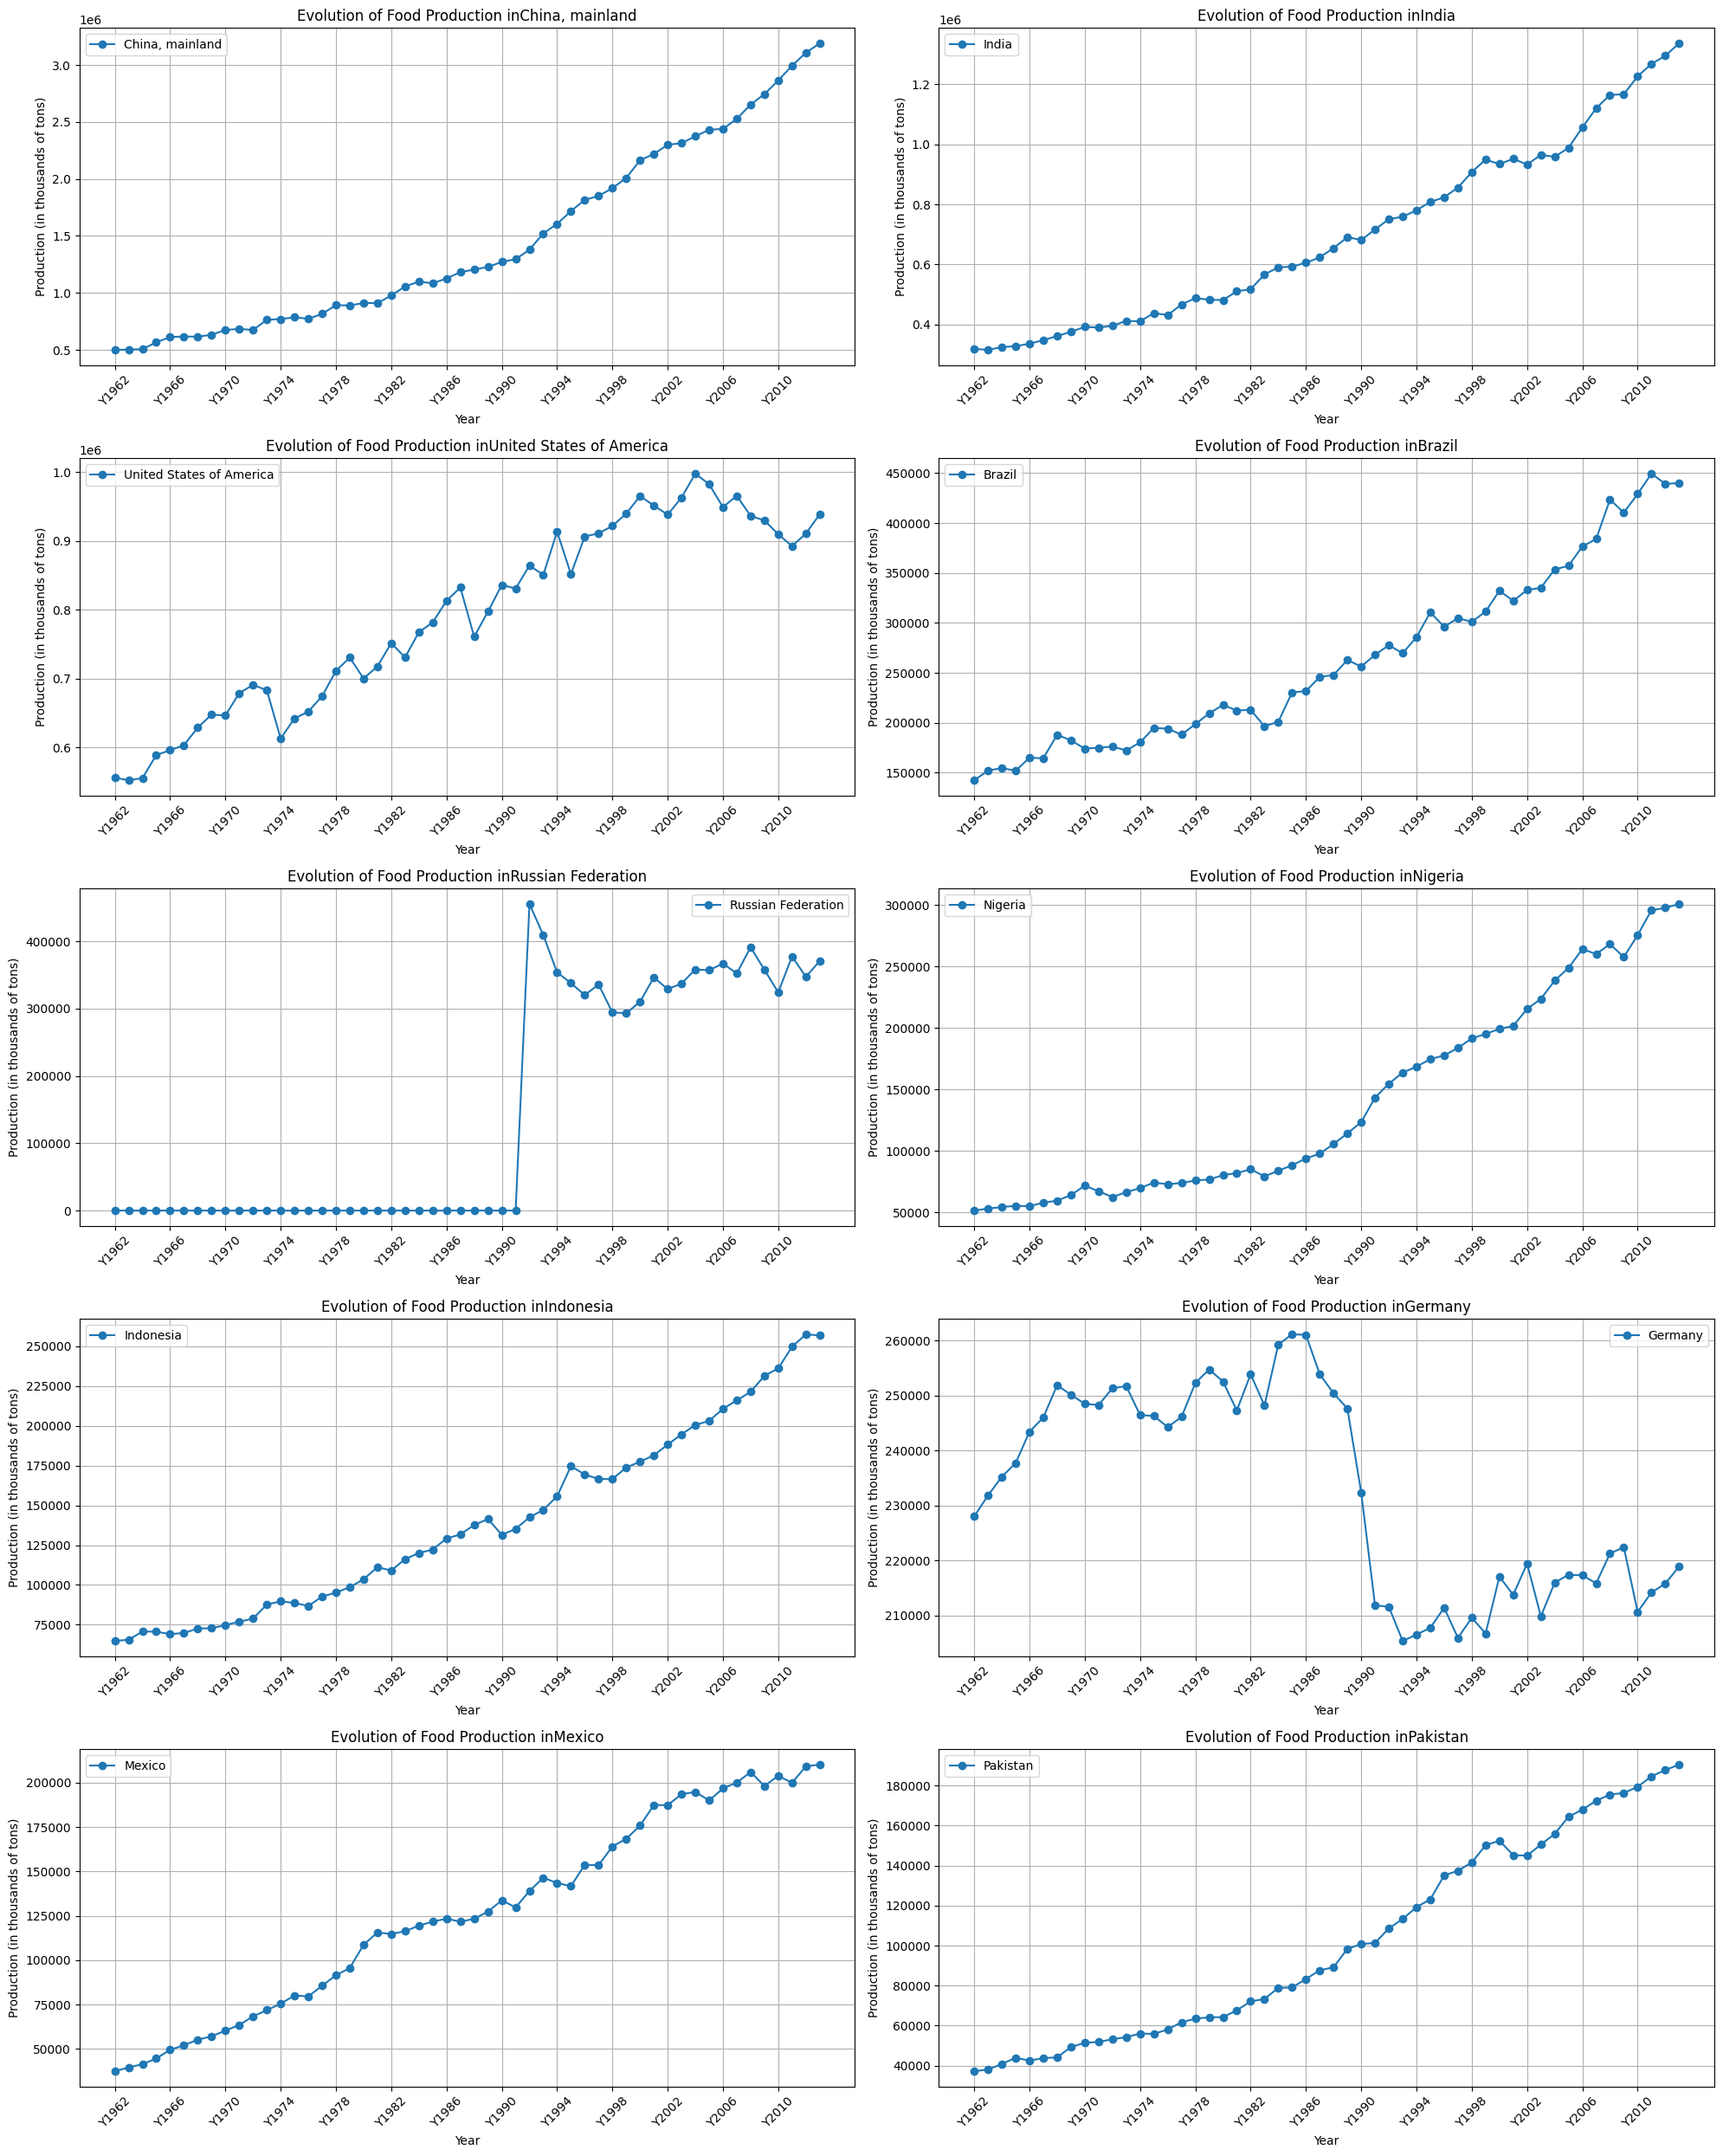

In [17]:
# Group by 'Area' and calculate the total production for each country, selecting the top 10.
top_10_countries = fao_data_cleaned.groupby('Area')['Y2013'].sum().sort_values(ascending=False).head(10).index.tolist()

fig, axes = plt.subplots(5, 2, figsize=(20, 25))
axes = axes.flatten()

for i, country in enumerate(top_10_countries):
   
    country_data = fao_data_cleaned[fao_data_cleaned['Area'] == country].iloc[:, 6:]
    country_data_sum = country_data.sum()
    
    
    axes[i].plot(country_data_sum.index, country_data_sum.values, marker='o', linestyle='-', label=country)
    axes[i].set_title(f'Evolution of Food Production in{country}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Production (in thousands of tons)')
    axes[i].grid(True)
    axes[i].legend()
    
    # Rotation of x-axis labels and selection of one label every 4.
    axes[i].set_xticks(axes[i].get_xticks()[::4])
    axes[i].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

- Distribution of production by product type

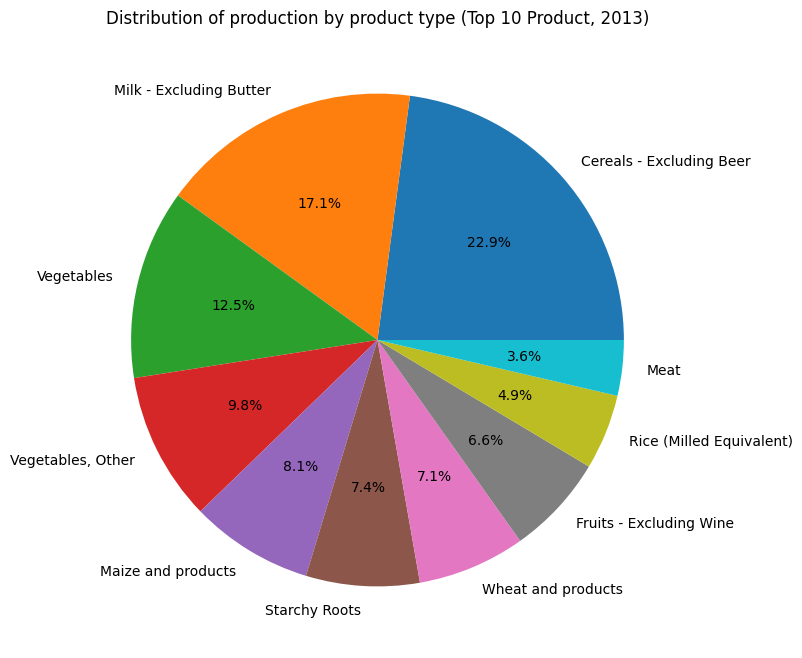

In [18]:
product_distribution = fao_data_cleaned.groupby('Item')['Y2013'].sum().sort_values(ascending=False).head(10)
product_distribution.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))
plt.title('Distribution of production by product type (Top 10 Product, 2013)')
plt.ylabel('')
plt.show()


- Wheat production over time

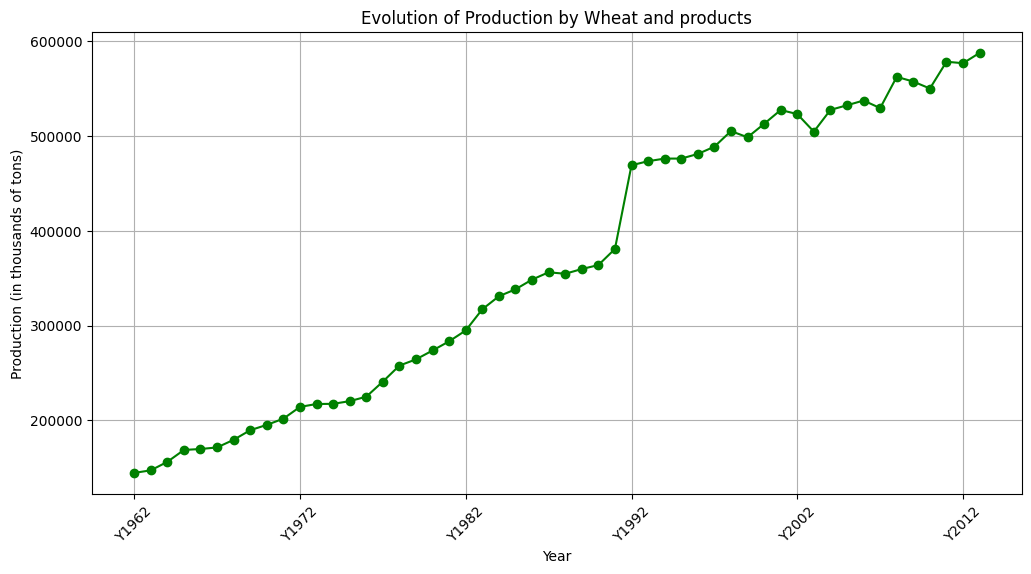

In [19]:
product = 'Wheat and products'
product_data = fao_data_cleaned[fao_data_cleaned['Item'] == product].iloc[:, 6:]
product_data_sum = product_data.sum()

plt.figure(figsize=(12, 6))
product_data_sum.plot(kind='line', marker='o', color='g')
plt.xlabel('Year')
plt.ylabel('Production (in thousands of tons)')
plt.title(f'Evolution of Production by {product}')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


From the exploratory analysis of the FAO dataset, it emerges that global food production is concentrated in a few key countries, such as China, India, and the United States. These countries exhibit significant growth in production, likely due to agricultural innovations and a large availability of fertile land. Production is heavily dominated by cereals (wheat, rice, maize), highlighting a global dependency that could be vulnerable to crises. There is a notable imbalance in production capacity between countries, suggesting the need for technological support to low-income countries to enhance global food security.

WASTE

- Top 10 countries for food waste

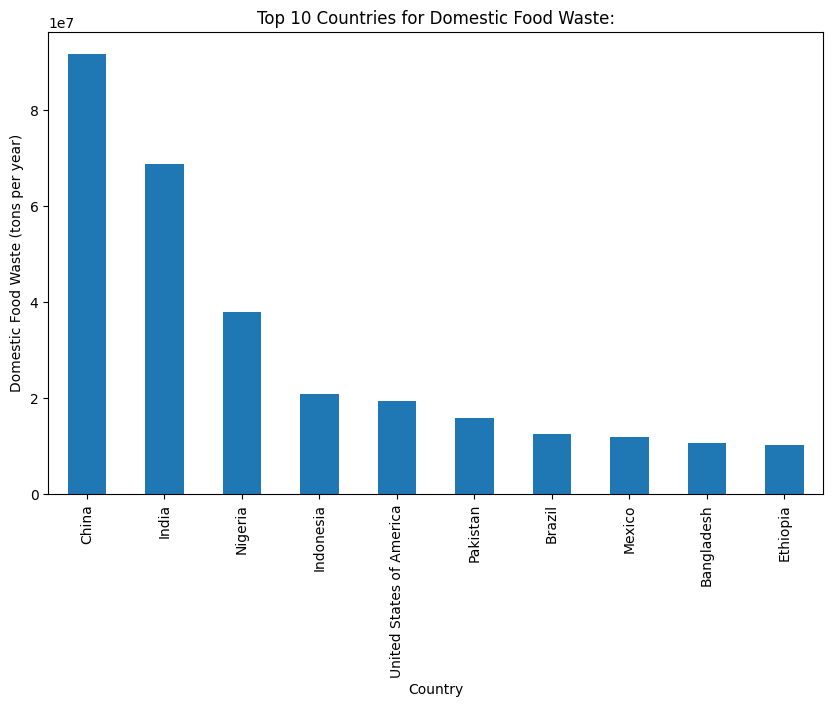

In [20]:
food_waste_data = datasets['Food Waste']

# Select the top 10 countries for food waste using the column names from the original dataset
top_10_waste_countries = food_waste_data.groupby('Country')['Household estimate (tonnes/year)'].sum().sort_values(ascending=False).head(10)

# Create a bar chart for the top 10 countries with the highest food waste
top_10_waste_countries.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Country')
plt.ylabel('Domestic Food Waste (tons per year)')
plt.title('Top 10 Countries for Domestic Food Waste:')
plt.show()


The graph shows that China and India are the countries with the highest levels of domestic food waste, significantly surpassing all others. This is linked to their large populations and rapid economic development. Nigeria also appears on the list, indicating a significant level of waste, likely due to inefficiencies in storage infrastructure. Other countries, such as the United States and Indonesia, also exhibit high levels of waste, which can be associated with high levels of consumerism.

FOOD PRODUCTION

- Top 10 paesi for emission

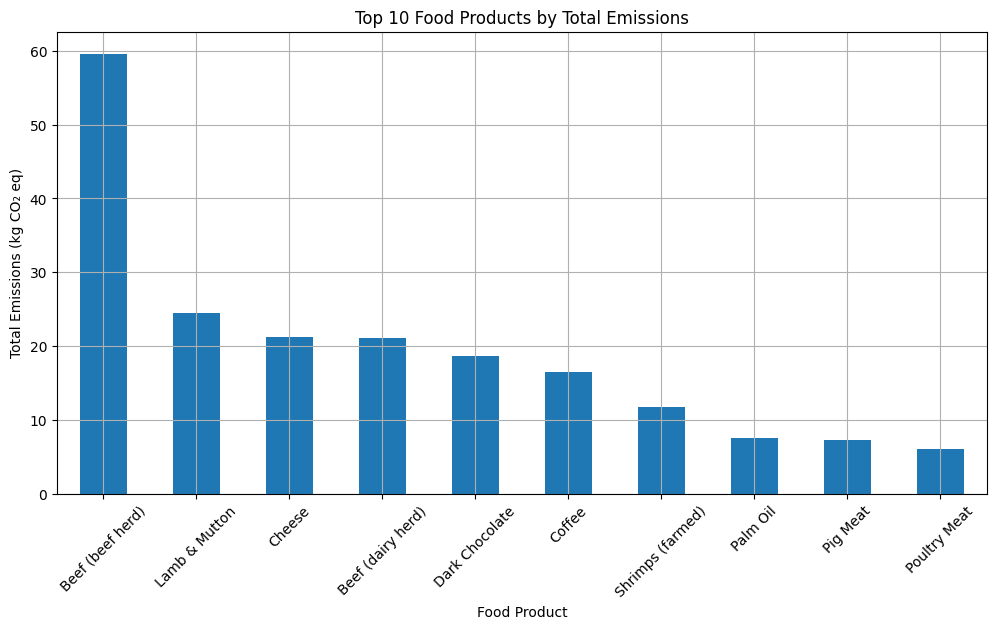

In [21]:
top_emission_products = datasets['Food Production'].groupby('Food product')['Total_emissions'].sum().sort_values(ascending=False).head(10)

top_emission_products.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Food Product')
plt.ylabel('Total Emissions (kg CO₂ eq)')
plt.title('Top 10 Food Products by Total Emissions')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

- Water demand per product

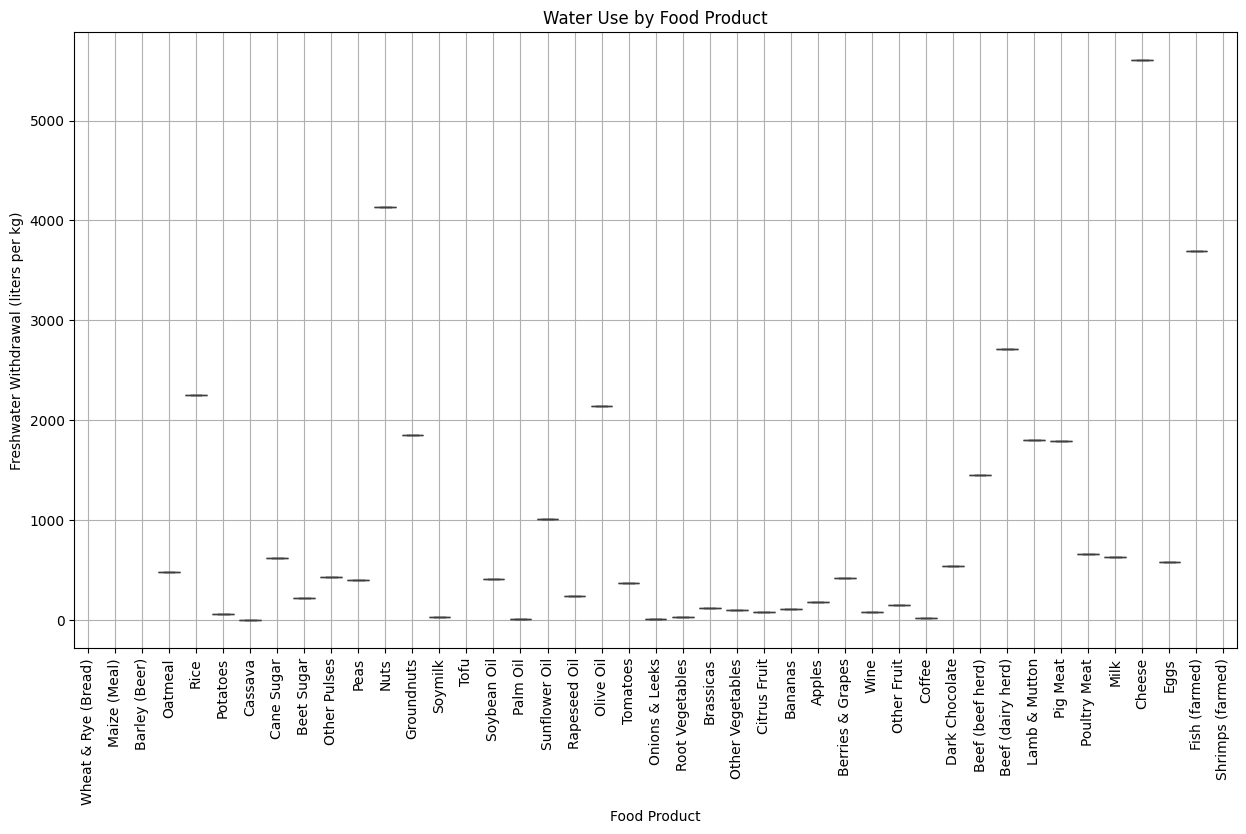

In [22]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=datasets['Food Production'], x='Food product', y='Freshwater withdrawals per kilogram (liters per kilogram)')
plt.xlabel('Food Product')
plt.ylabel('Freshwater Withdrawal (liters per kg)')
plt.title('Water Use by Food Product')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

- Top 10 products by emissions

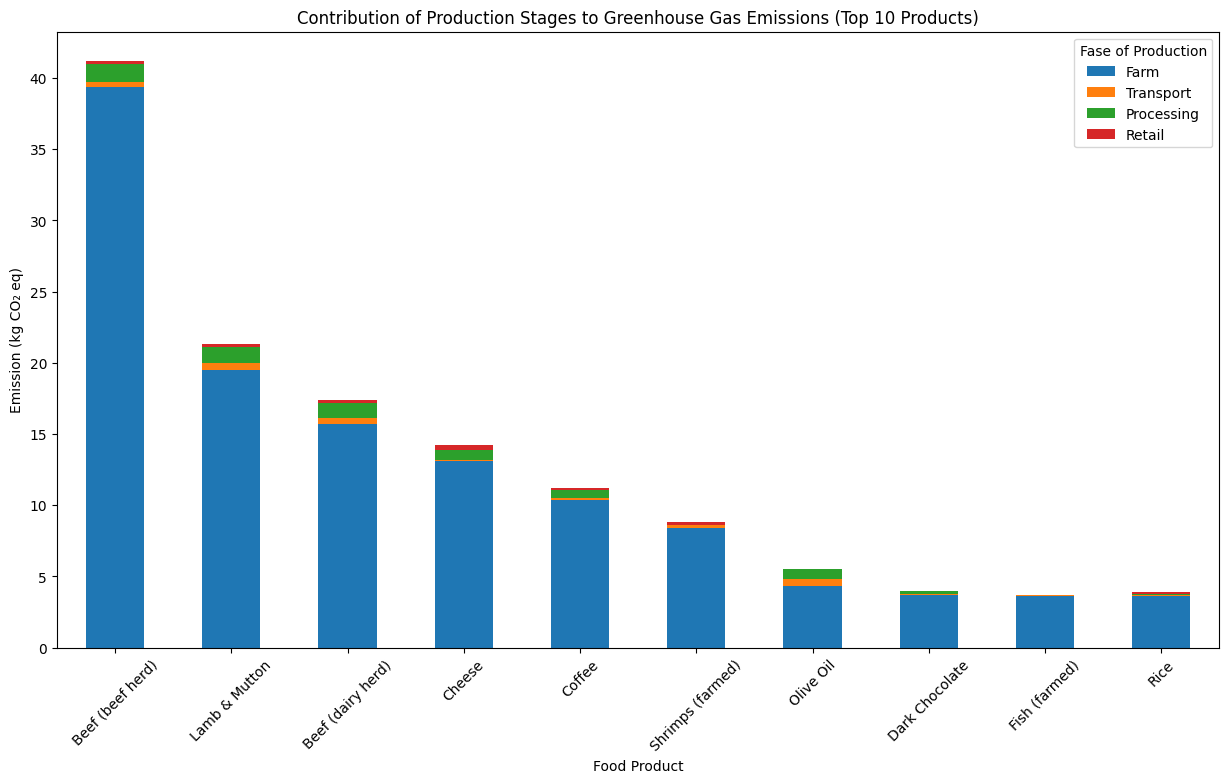

In [23]:
emissions_by_phase = food_production_data_cleaned[['Food product', 'Farm', 'Transport', 'Processing', 'Retail']].groupby('Food product').sum().sort_values('Farm', ascending=False).head(10)
emissions_by_phase.plot(kind='bar', stacked=True, figsize=(15, 8))
plt.xlabel('Food Product')
plt.ylabel('Emission (kg CO₂ eq)')
plt.title('Contribution of Production Stages to Greenhouse Gas Emissions (Top 10 Products)')
plt.xticks(rotation=45)
plt.legend(title='Fase of Production')
plt.show()

Beef is the product with the highest environmental impact, both in terms of greenhouse gas emissions and water consumption, followed by lamb and cheese (most emissions originate from the agricultural phase). Products like chocolate and coffee require significant amounts of water; this analysis highlights how a diet that reduces the consumption of meat and dairy could significantly lower the ecological footprint while promoting the use of less resource-intensive products.

GHI

- Top 10 paesi con ghi piu alto

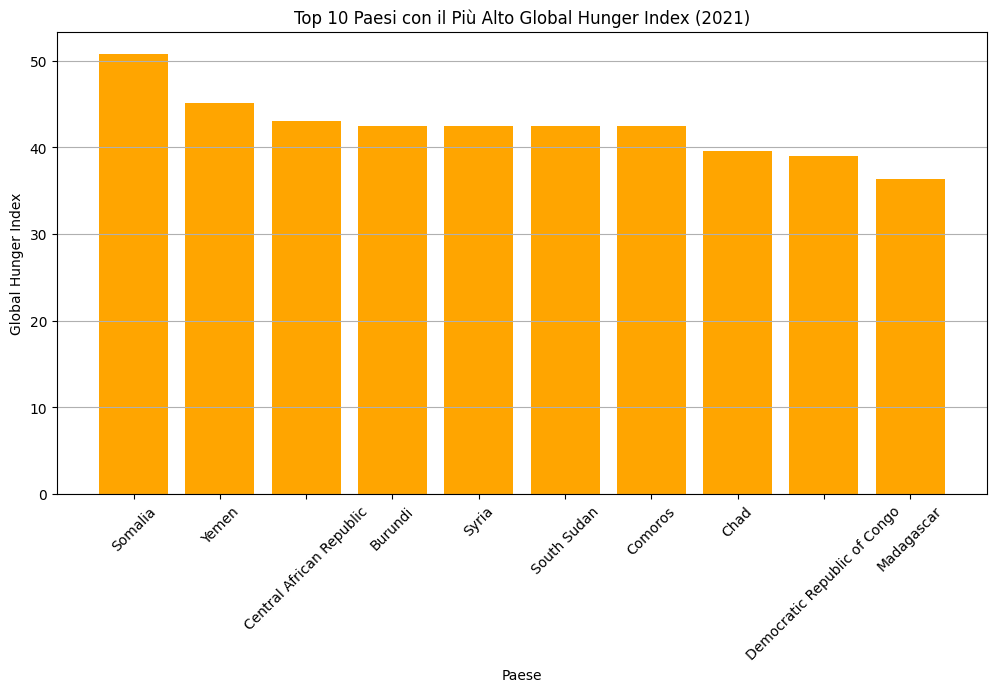

In [24]:
# Filter the most recent year available in the dataset.
latest_year = ghi_data_cleaned['Year'].max()
latest_data = ghi_data_cleaned[ghi_data_cleaned['Year'] == latest_year]

# Select the top 10 countries with the highest GHI value.
top_10_ghi = latest_data.sort_values(by='Global Hunger Index (2021)', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_10_ghi['Entity'], top_10_ghi['Global Hunger Index (2021)'], color='orange')
plt.xlabel('Paese')
plt.ylabel('Global Hunger Index')
plt.title(f'Top 10 Paesi con il Più Alto Global Hunger Index ({latest_year})')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


- Comparison between top Africa and top Asia.

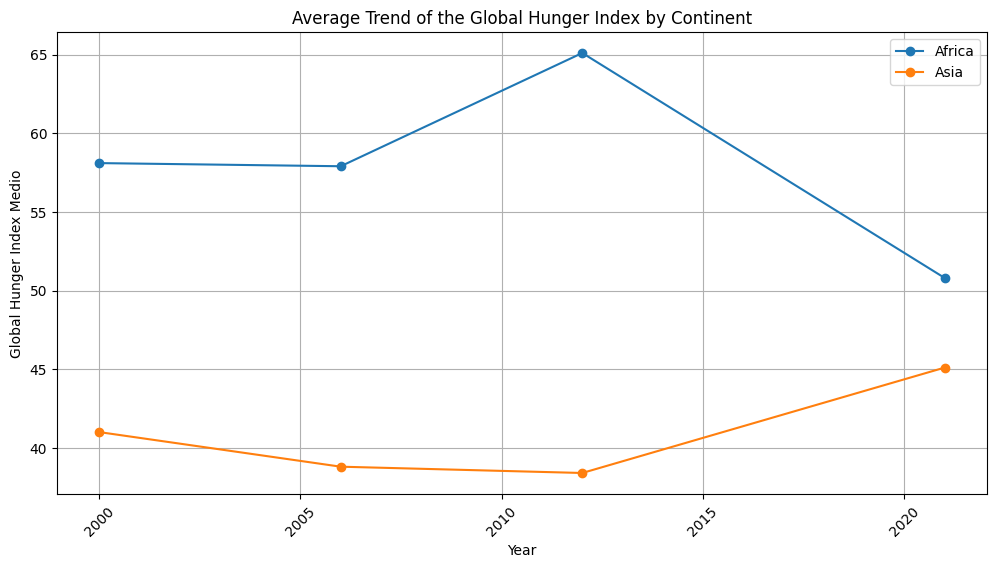

In [25]:
# Add a column for continents.
continent_mapping = {
    'Yemen': 'Asia',
    'Somalia': 'Africa',
    
}
ghi_data_cleaned['Continent'] = ghi_data_cleaned['Entity'].map(continent_mapping)

# Calculate the average GHI for each continent over the years.
ghi_data_continent = ghi_data_cleaned.groupby(['Continent', 'Year'])['Global Hunger Index (2021)'].mean().reset_index()

plt.figure(figsize=(12, 6))
for continent in ghi_data_continent['Continent'].unique():
    data = ghi_data_continent[ghi_data_continent['Continent'] == continent]
    plt.plot(data['Year'], data['Global Hunger Index (2021)'], marker='o', label=continent)

plt.xlabel('Year')
plt.ylabel('Global Hunger Index Medio')
plt.title('Average Trend of the Global Hunger Index by Continent')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


From the Global Hunger Index (GHI), serious problems of food insecurity emerge in countries like Somalia, Yemen, and Syria, with GHI values exceeding 40, indicating critical levels of hunger. The evolution of the GHI for the Central African Republic shows a slight improvement in recent years, but the value remains high. The latest chart reveals that Africa maintains a higher average GHI compared to Asia, with a slower trend of improvement.

GNI

In [26]:
gni_data = datasets['Gross National Income']
gni_data.head()


,Entity,Code,Year,"GNI per capita, PPP (constant 2017 international $)"
0,Afghanistan,AFG,2017,2085.487571
1,Africa Eastern and Southern,NaN,1990,2554.595257
2,Africa Eastern and Southern,NaN,1991,2495.966953
3,Africa Eastern and Southern,NaN,1992,2421.787983
4,Africa Eastern and Southern,NaN,1993,2397.012790


- Top 10 paesi con Gni piu alto

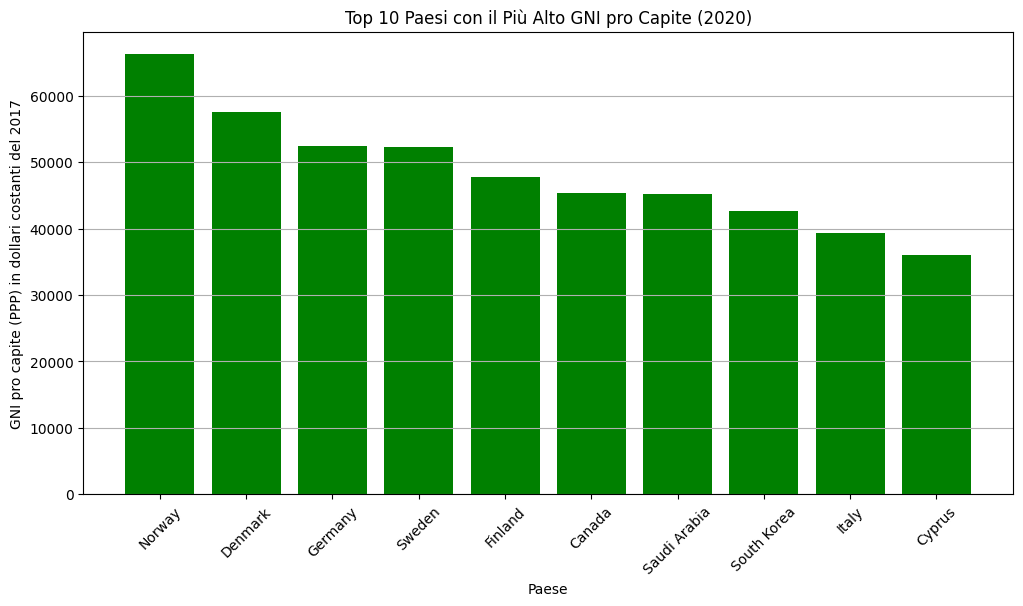

In [27]:
# Convert the 'Year' column to numeric format to avoid problems
gni_data['Year'] = pd.to_numeric(gni_data['Year'], errors='coerce')

latest_year = gni_data['Year'].max()
latest_data = gni_data[gni_data['Year'] == latest_year]

top_10_gni = latest_data.sort_values(by='GNI per capita, PPP (constant 2017 international $)', ascending=False).head(10)


plt.figure(figsize=(12, 6))
plt.bar(top_10_gni['Entity'], top_10_gni['GNI per capita, PPP (constant 2017 international $)'], color='green')
plt.xlabel('Paese')
plt.ylabel('GNI pro capite (PPP) in dollari costanti del 2017')
plt.title(f'Top 10 Paesi con il Più Alto GNI pro Capite ({latest_year})')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


- Top 10 paesi con Gni piu basso

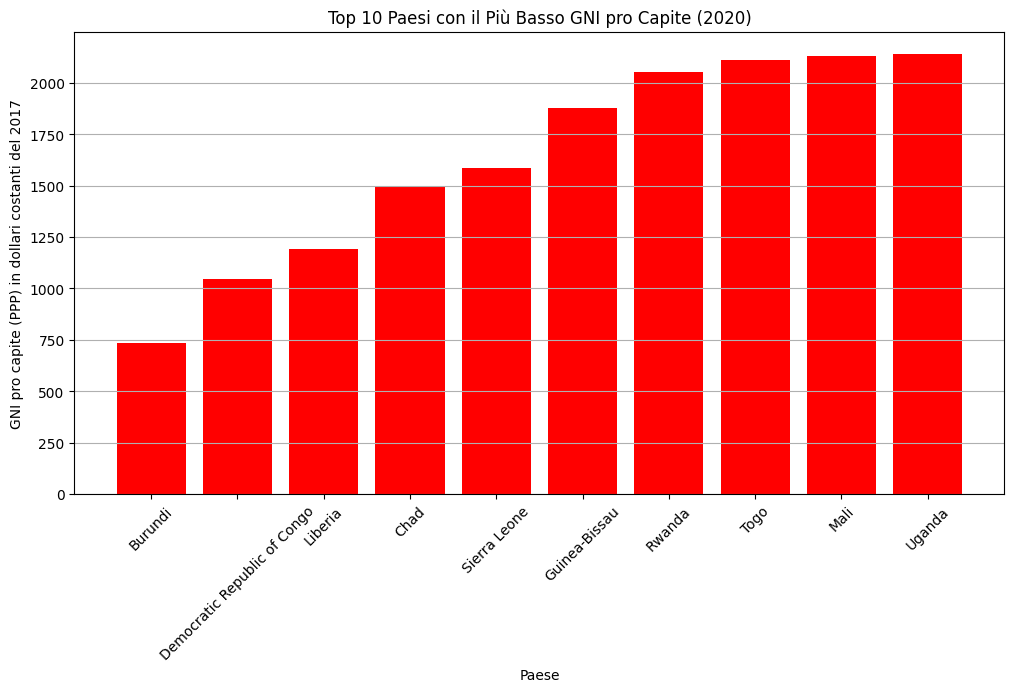

In [28]:
latest_year = gni_data['Year'].max()
latest_data = gni_data[gni_data['Year'] == latest_year]

bottom_10_gni = latest_data.sort_values(by='GNI per capita, PPP (constant 2017 international $)', ascending=True).head(10)

plt.figure(figsize=(12, 6))
plt.bar(bottom_10_gni['Entity'], bottom_10_gni['GNI per capita, PPP (constant 2017 international $)'], color='red')
plt.xlabel('Paese')
plt.ylabel('GNI pro capite (PPP) in dollari costanti del 2017')
plt.title(f'Top 10 Paesi con il Più Basso GNI pro Capite ({latest_year})')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

The two charts show a clear disparity in the distribution of Gross National Income (GNI) per capita between the countries with the highest and lowest GNI in 2020. Countries with the highest GNI, such as Norway and Denmark, exceed 50,000 PPP dollars, while countries with the lowest GNI, like Burundi and the Democratic Republic of the Congo, register less than 1,000 PPP dollars.

HUMAN DEVELOPMENT

- Top 10 paesi con Hdi piu alto

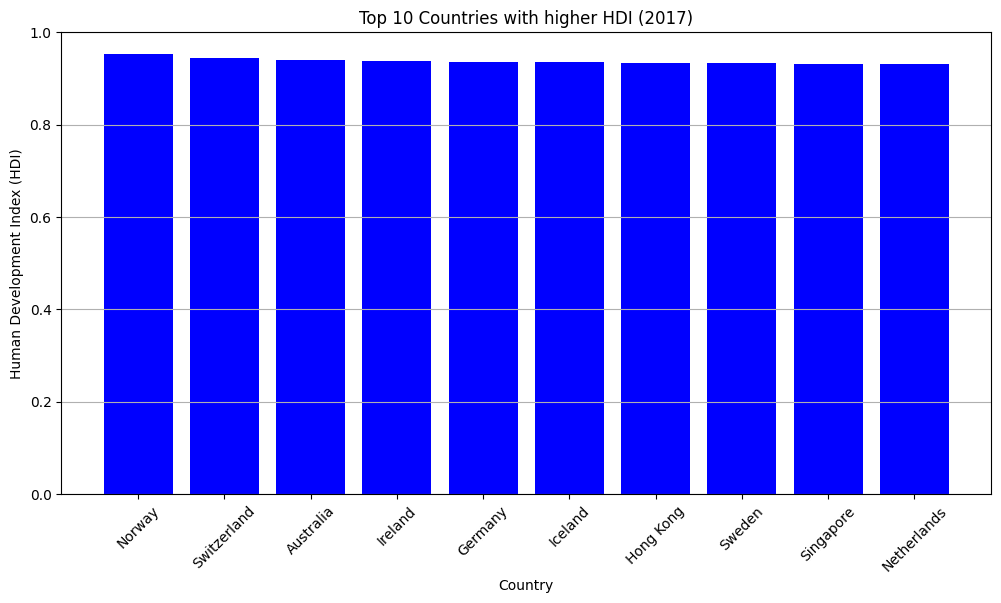

In [29]:
dataset_human_development = datasets['Human Development Index']

latest_year = dataset_human_development['Year'].max()
latest_data = dataset_human_development[dataset_human_development['Year'] == latest_year]

top_10_hdi = latest_data.sort_values(by='Human Development Index (UNDP)', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_10_hdi['Entity'], top_10_hdi['Human Development Index (UNDP)'], color='blue')
plt.xlabel('Country')
plt.ylabel('Human Development Index (HDI)')
plt.title(f'Top 10 Countries with higher HDI ({latest_year})')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


- top 10 Countries with lower HDI

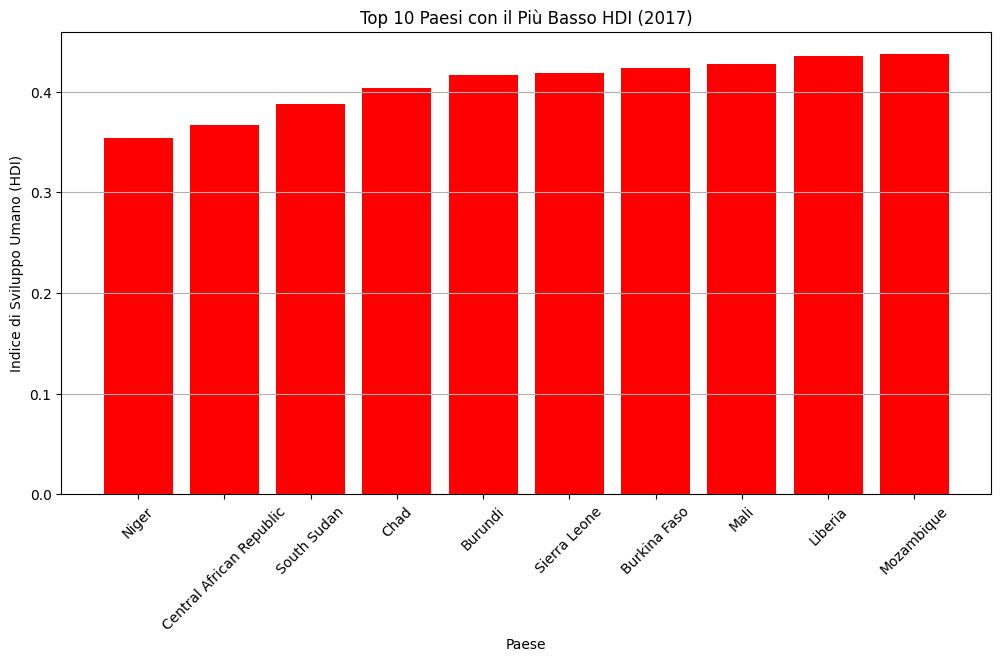

In [30]:
bottom_10_hdi = latest_data.sort_values(by='Human Development Index (UNDP)', ascending=True).head(10)

plt.figure(figsize=(12, 6))
plt.bar(bottom_10_hdi['Entity'], bottom_10_hdi['Human Development Index (UNDP)'], color='red')
plt.xlabel('Paese')
plt.ylabel('Indice di Sviluppo Umano (HDI)')
plt.title(f'Top 10 Paesi con il Più Basso HDI ({latest_year})')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


The two charts show the contrast between countries with the highest and lowest Human Development Index (HDI) in 2017. Countries with the highest HDI, such as Norway, Switzerland, and Australia, have values very close to 1, indicating a high level of socioeconomic development and a high quality of life. In contrast, countries with the lowest HDI, such as Niger and the Central African Republic, record values around 0.3-0.4, showing significant challenges in terms of development, quality of life, and access to basic services.

MEET CONSUPTION

- Meet Consuption over time

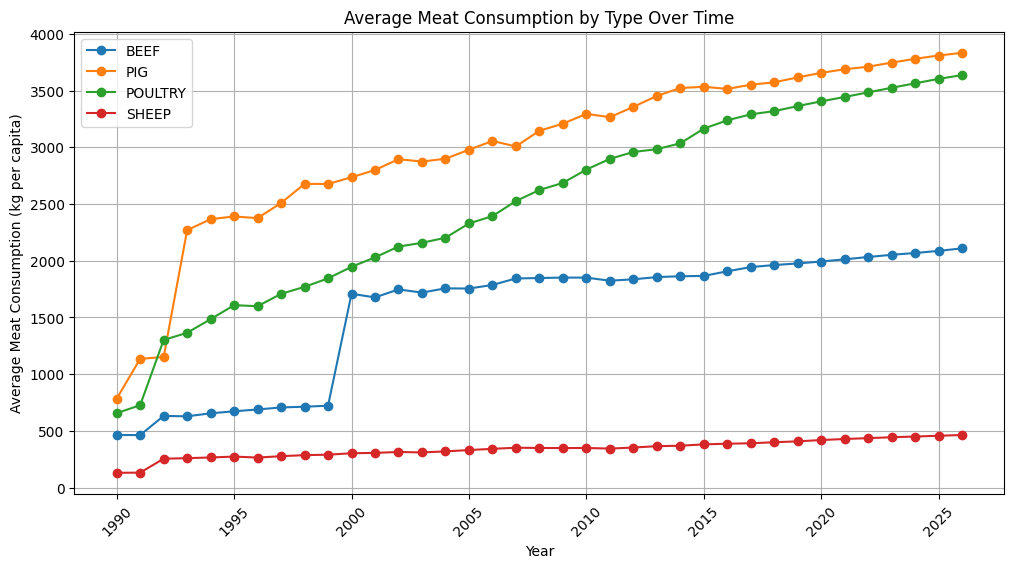

In [31]:
dataset_meat_consumption = datasets['Meat Consumption']

# 'TIME' and 'SUBJECT' for calculating average consumption
average_consumption = dataset_meat_consumption.groupby(['TIME', 'SUBJECT'])['Value'].mean().reset_index()

# Create a line graph to visualize the average meat consumption by type over time
plt.figure(figsize=(12, 6))
for meat_type in average_consumption['SUBJECT'].unique():
    subset = average_consumption[average_consumption['SUBJECT'] == meat_type]
    plt.plot(subset['TIME'], subset['Value'], marker='o', linestyle='-', label=meat_type)

plt.xlabel('Year')
plt.ylabel('Average Meat Consumption (kg per capita)')
plt.title('Average Meat Consumption by Type Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

- Top 10 countries for meat consumption

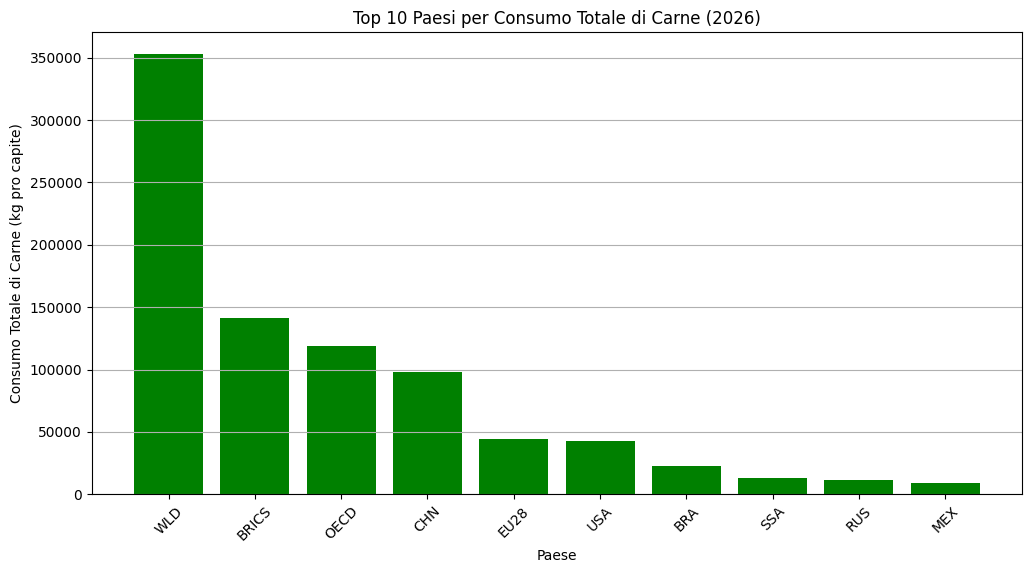

In [32]:

latest_year = dataset_meat_consumption['TIME'].max()
latest_data = dataset_meat_consumption[dataset_meat_consumption['TIME'] == latest_year]

# Group by 'LOCATION' to find total meat consumption
total_consumption_per_country = latest_data.groupby('LOCATION')['Value'].sum().sort_values(ascending=False).head(10)


plt.figure(figsize=(12, 6))
plt.bar(total_consumption_per_country.index, total_consumption_per_country.values, color='green')
plt.xlabel('Paese')
plt.ylabel('Consumo Totale di Carne (kg pro capite)')
plt.title(f'Top 10 Paesi per Consumo Totale di Carne ({latest_year})')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

- Consumption of different types of meat in 2020 and 2000

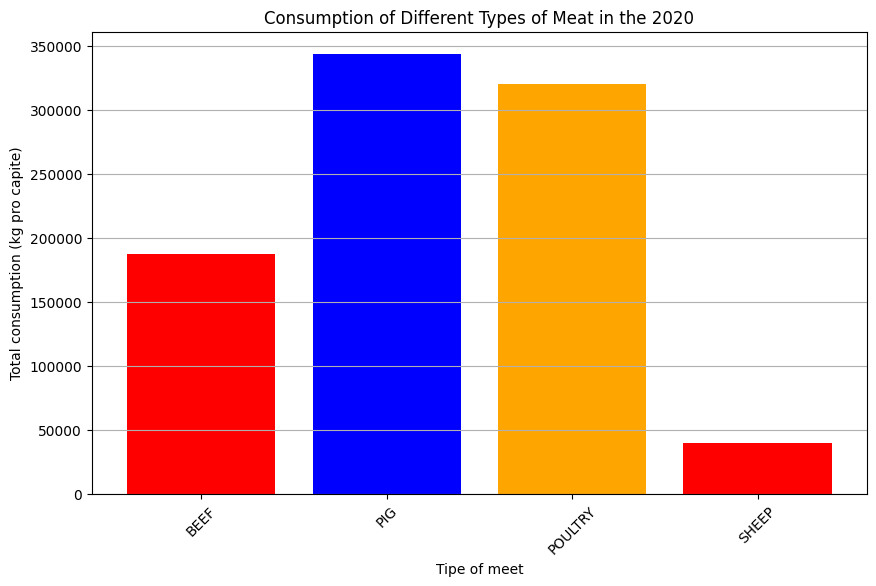

In [33]:
selected_year = 2020
year_data = dataset_meat_consumption[dataset_meat_consumption['TIME'] == selected_year]

# Group by 'SUBJECT' and calculate the total consumption
total_consumption_per_meat = year_data.groupby('SUBJECT')['Value'].sum().reset_index()


plt.figure(figsize=(10, 6))
plt.bar(total_consumption_per_meat['SUBJECT'], total_consumption_per_meat['Value'], color=['red', 'blue', 'orange'])
plt.xlabel('Tipe of meet')
plt.ylabel('Total consumption (kg pro capite)')
plt.title(f'Consumption of Different Types of Meat in the {selected_year}')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

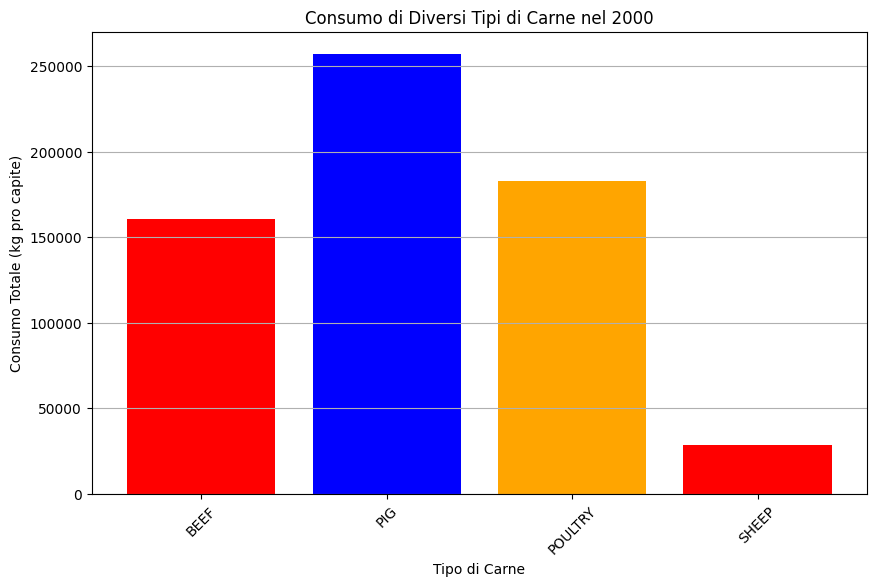

In [34]:
selected_year = 2000
year_data = dataset_meat_consumption[dataset_meat_consumption['TIME'] == selected_year]

total_consumption_per_meat = year_data.groupby('SUBJECT')['Value'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(total_consumption_per_meat['SUBJECT'], total_consumption_per_meat['Value'], color=['red', 'blue', 'orange'])
plt.xlabel('Tipo di Carne')
plt.ylabel('Consumo Totale (kg pro capite)')
plt.title(f'Consumo di Diversi Tipi di Carne nel {selected_year}')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


The charts show the trend of average meat consumption by type over time, with a clear increase in chicken consumption, which has surpassed all other categories. Pork follows as the second most consumed type of meat. In the chart related to the top 10 countries for total meat consumption in 2020, it is evident that emerging economies (BRICS) and developed nations (such as the OECD and the United States) are the largest consumers. Comparing meat consumption between 2000 and 2020, there is a significant increase in chicken consumption and general stability for beef and pork. This reflects a growing preference for white meat, often considered more sustainable and healthy.

CHILDREN UNDRWEIGHT

- Trend of the percentage of underweight children over time

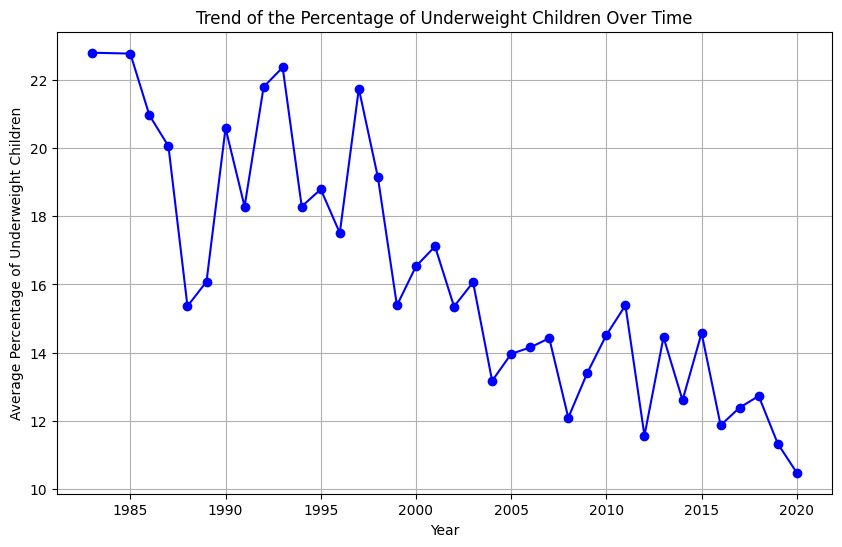

In [35]:
dataset_children_under_weight = datasets['Children Under Weight']

# Group by 'Year' and calculate the average percentage of underweight children
avg_underweight_per_year = dataset_children_under_weight.groupby('Year')['Prevalence of underweight, weight for age (% of children under 5)'].mean().reset_index()

# Create a line graph to visualize the distribution over time
plt.figure(figsize=(10, 6))
plt.plot(avg_underweight_per_year['Year'], avg_underweight_per_year['Prevalence of underweight, weight for age (% of children under 5)'], marker='o', linestyle='-', color='b')
plt.xlabel('Year')
plt.ylabel('Average Percentage of Underweight Children')
plt.title('Trend of the Percentage of Underweight Children Over Time')
plt.grid(True)
plt.show()


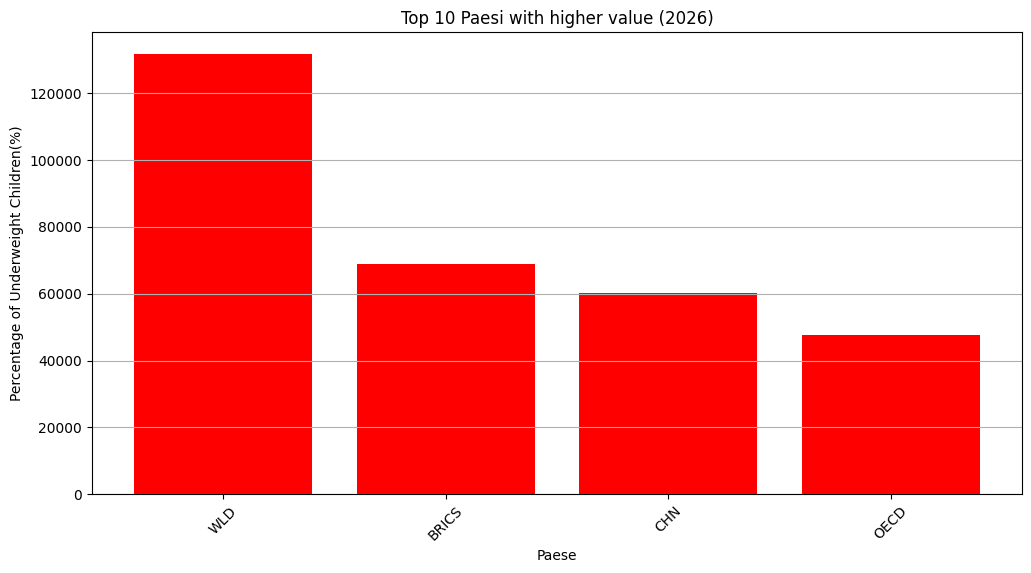

In [36]:
# Define a list of aggregations to exclude manually
aggregations_to_exclude = [
    'income', 'World', 'World Bank'
]

# Filter the entities to exclude aggregations using the list of aggregations to remove
filtered_countries = latest_data[~latest_data['LOCATION'].str.contains('|'.join(aggregations_to_exclude), case=False, na=False)]

# Select the top 10 countries with the highest value in the 'Value' column
top_10_countries_high = filtered_countries.sort_values(by='Value', ascending=False).head(10)


plt.figure(figsize=(12, 6))
plt.bar(top_10_countries_high['LOCATION'], top_10_countries_high['Value'], color='red')
plt.xlabel('Paese')
plt.ylabel('Percentage of Underweight Children(%)')
plt.title(f'Top 10 Paesi with higher value ({latest_data['TIME'].max()})') 
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

From the analysis of the percentage of underweight children, a significant decrease is observed from 1985 to 2020, with the average percentage dropping from 22% to less than 12%. However, in 2020, countries or regions such as South Asia and Nigeria still show high values of underweight children, with South Asia reaching 25%. This highlights that, despite global improvement, some regions continue to be particularly vulnerable to child malnutrition.

WORD FOOD PRODUCTION

In [37]:
world_food_production = datasets['World Food Production']
print(world_food_production.head())

        Entity  Year  Maize Production (tonnes)  Rice  Production ( tonnes)  \
0  Afghanistan  1961                   700000.0                    319000.0   
1  Afghanistan  1962                   700000.0                    319000.0   
2  Afghanistan  1963                   713000.0                    319000.0   
3  Afghanistan  1964                   720000.0                    380000.0   
4  Afghanistan  1965                   720000.0                    380000.0   

   Yams  Production (tonnes)  Wheat Production (tonnes)  \
0                  7467702.0                  2279000.0   
1                  7420515.0                  2279000.0   
2                  8479074.0                  1947000.0   
3                  9113779.0                  2230000.0   
4                 10067913.0                  2282000.0   

   Tomatoes Production (tonnes)  Tea  Production ( tonnes )  \
0                     1873812.0                     56315.0   
1                     2044797.0             

In [38]:
print(world_food_production.info())
print(world_food_production.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11912 entries, 0 to 11911
Data columns (total 24 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Entity                               11912 non-null  object 
 1   Year                                 11912 non-null  int64  
 2   Maize Production (tonnes)            11912 non-null  float64
 3   Rice  Production ( tonnes)           11912 non-null  float64
 4   Yams  Production (tonnes)            11912 non-null  float64
 5   Wheat Production (tonnes)            11912 non-null  float64
 6   Tomatoes Production (tonnes)         11912 non-null  float64
 7   Tea  Production ( tonnes )           11912 non-null  float64
 8   Sweet potatoes  Production (tonnes)  11912 non-null  float64
 9   Sunflower seed  Production (tonnes)  11912 non-null  float64
 10  Sugar cane Production (tonnes)       11912 non-null  float64
 11  Soybeans  Production (tonnes

- Top 10 food producer

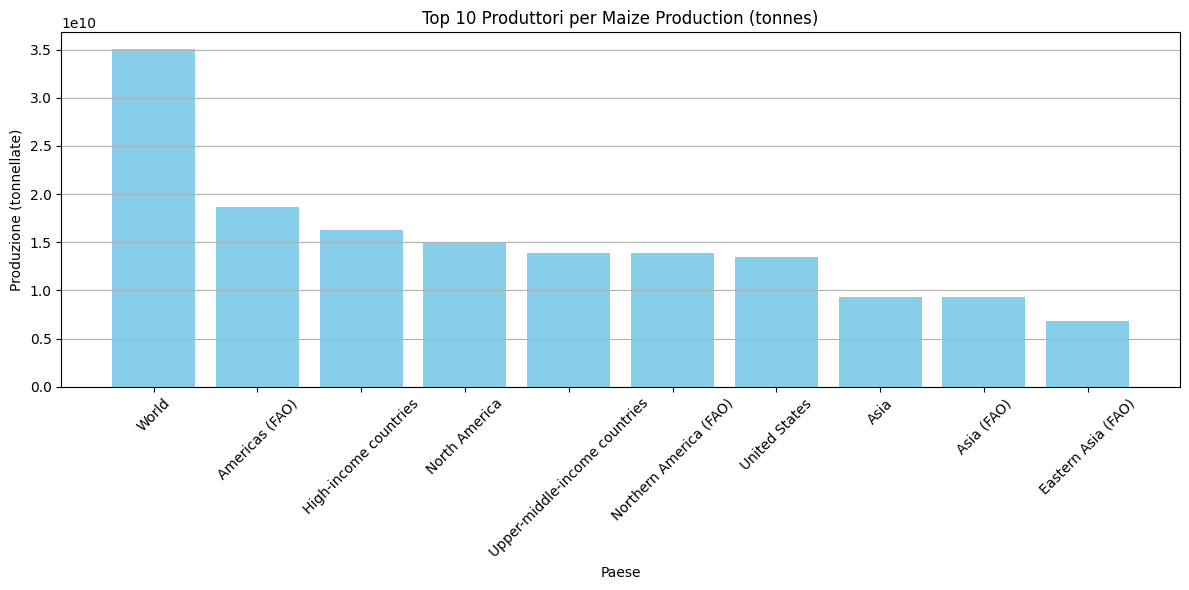

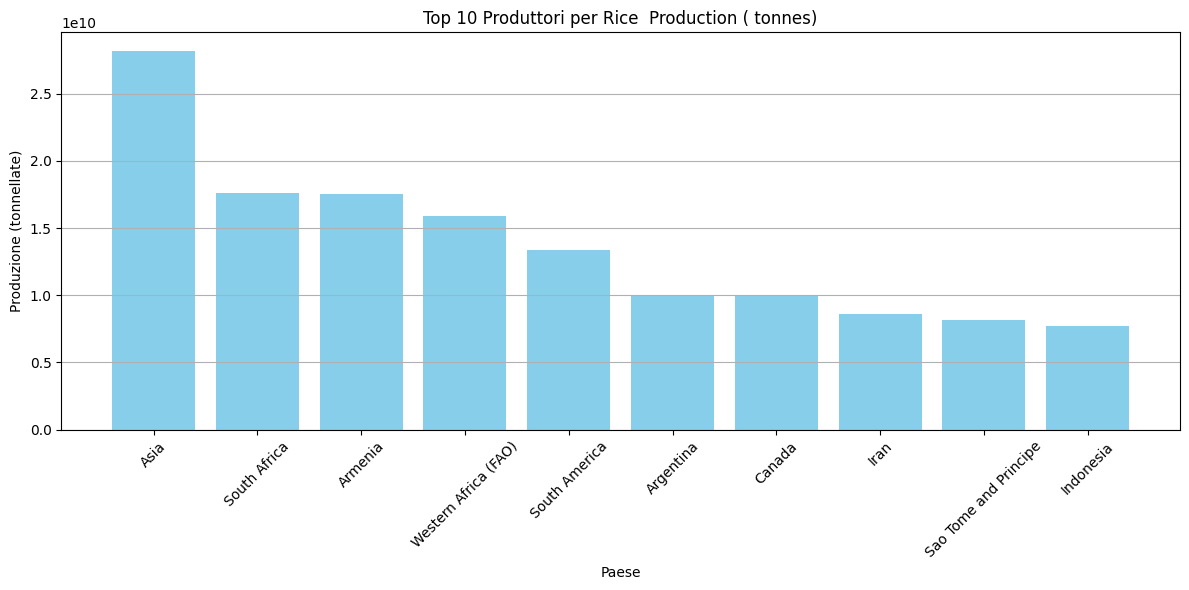

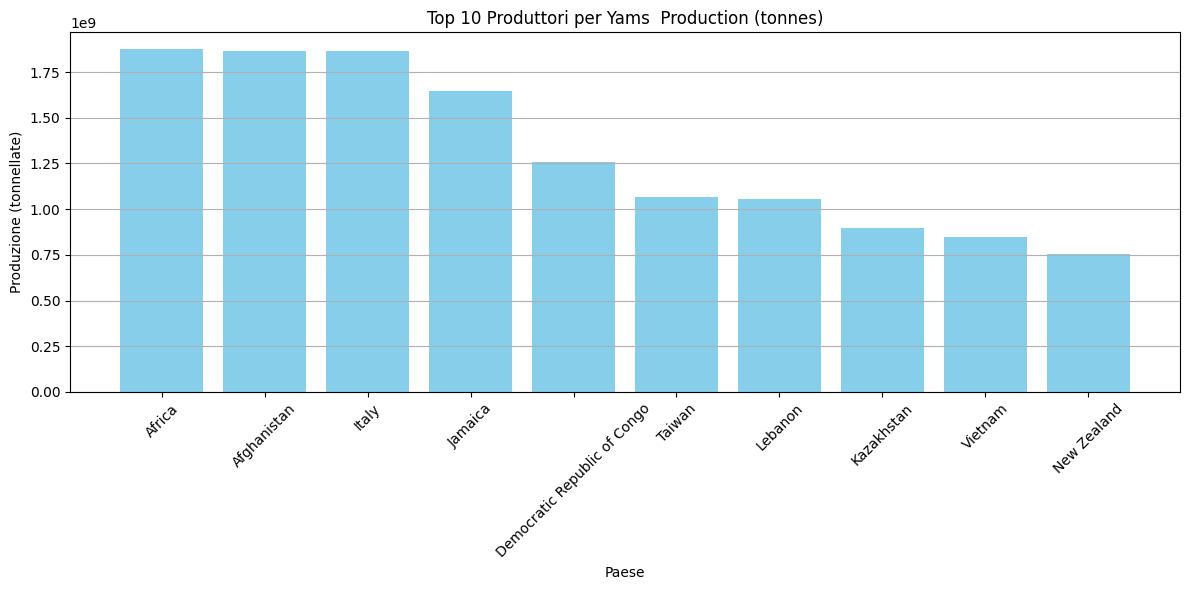

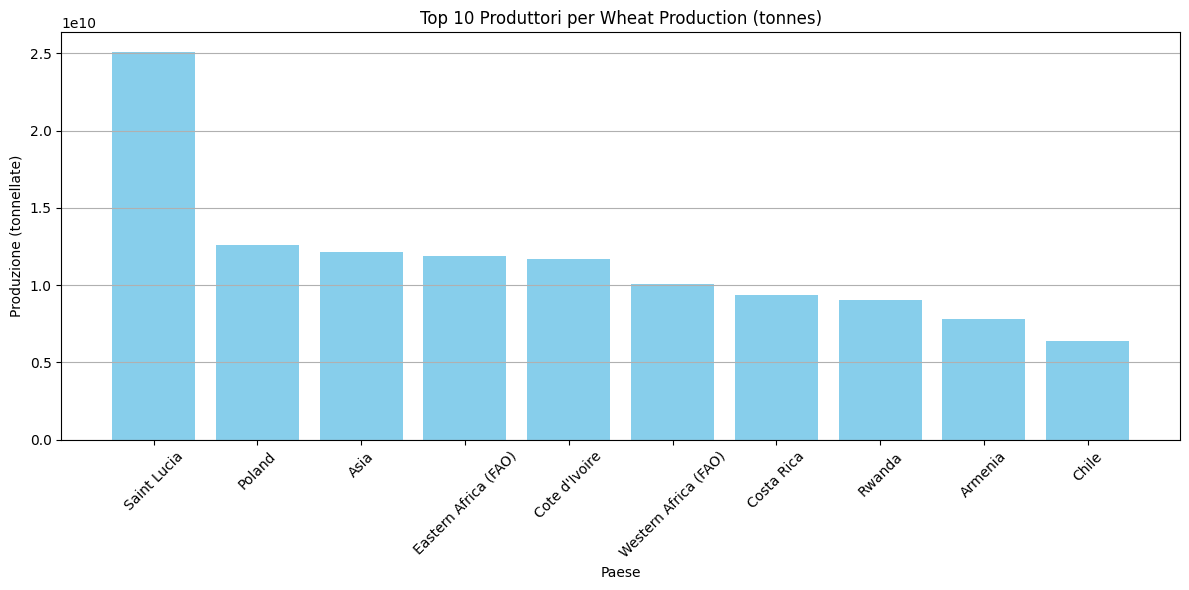

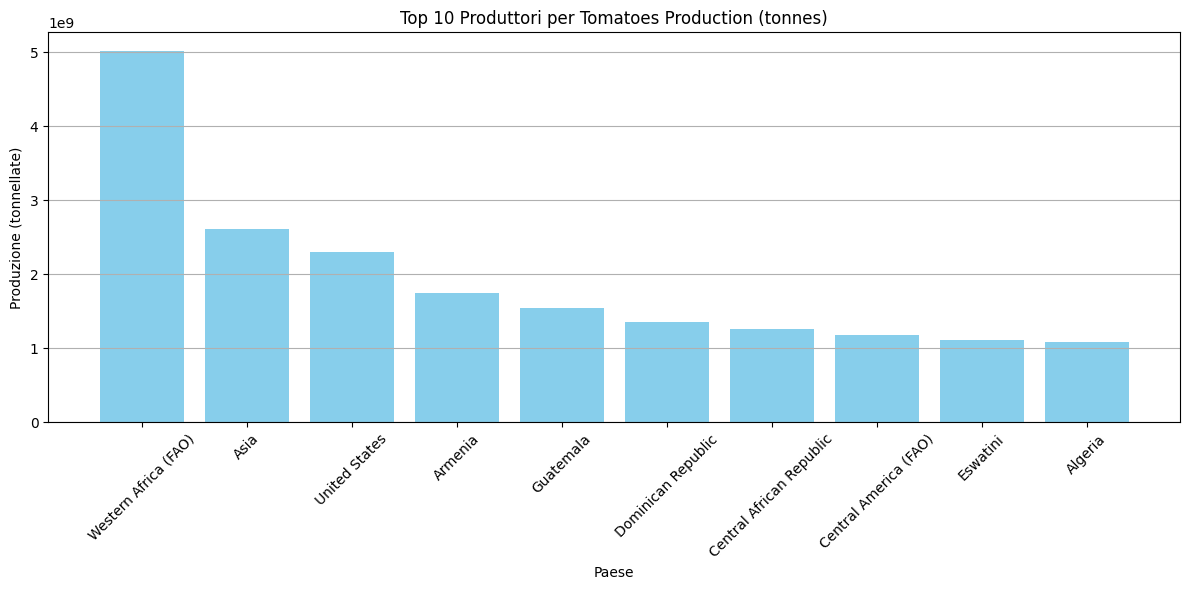

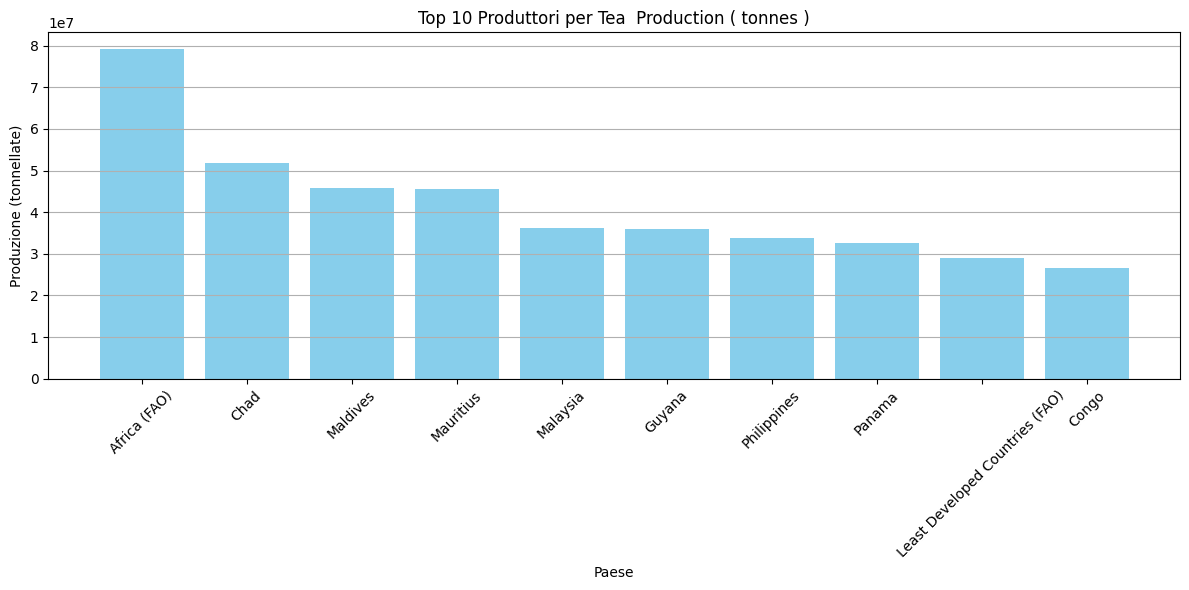

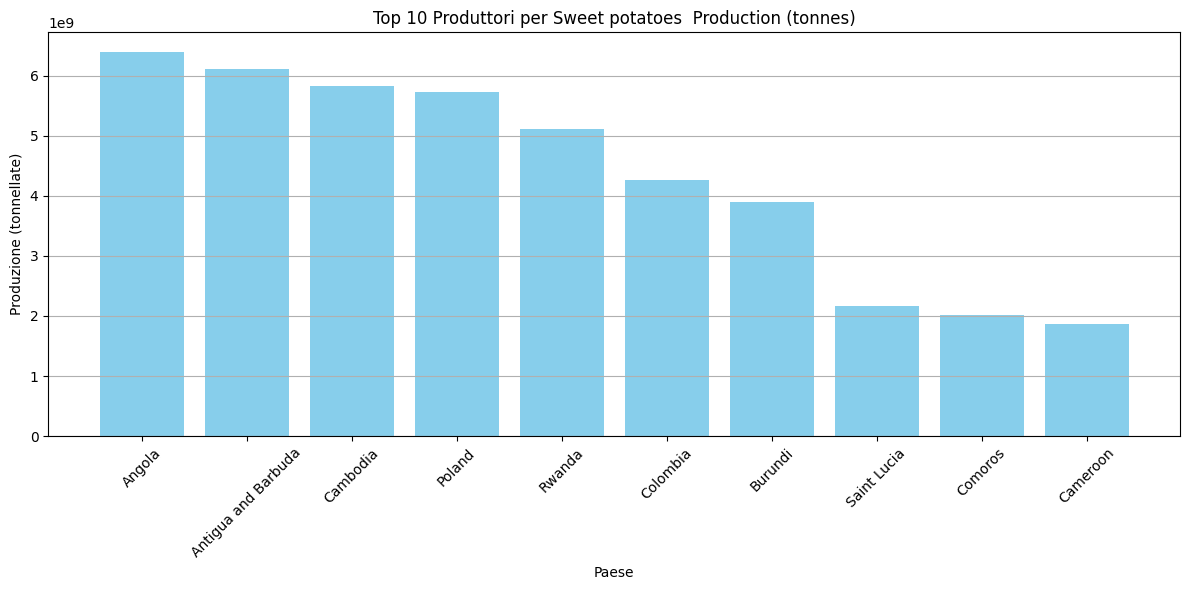

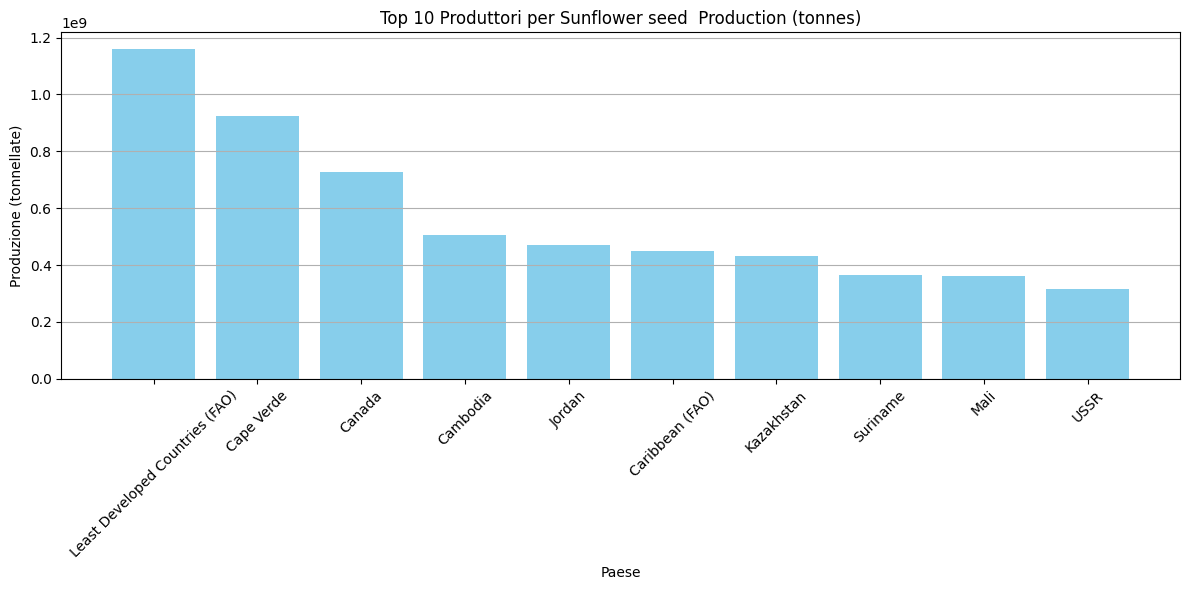

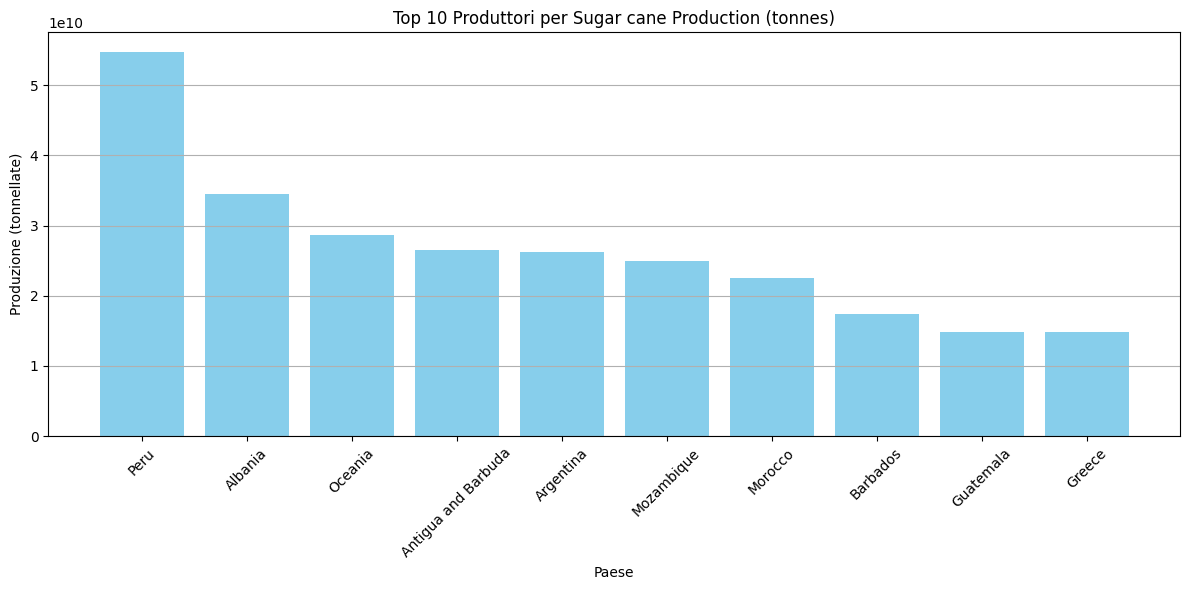

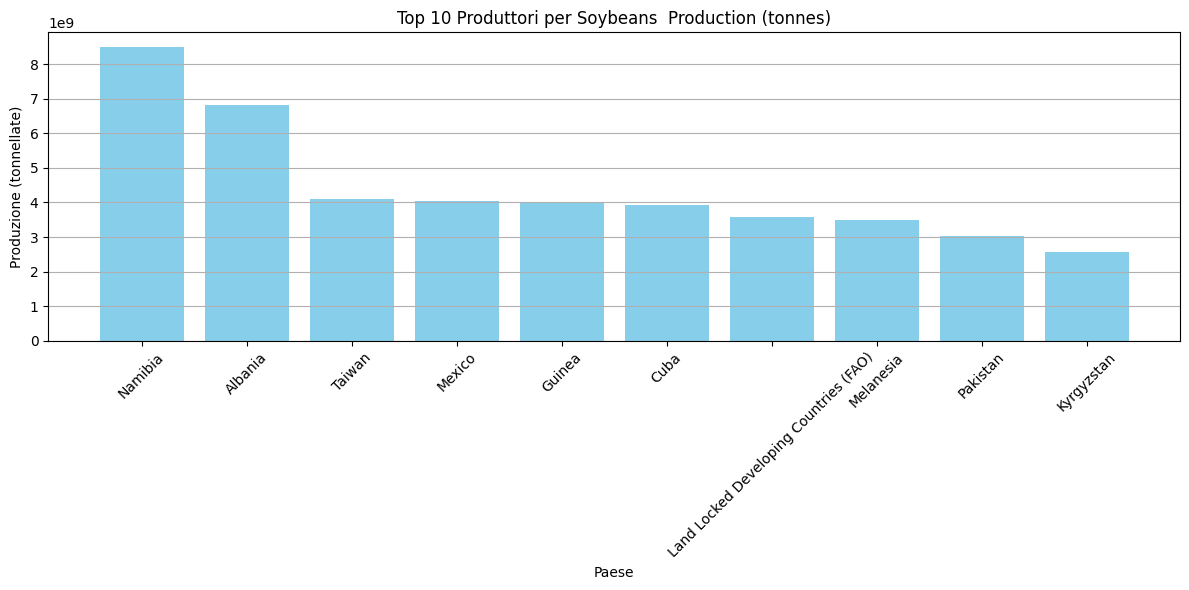

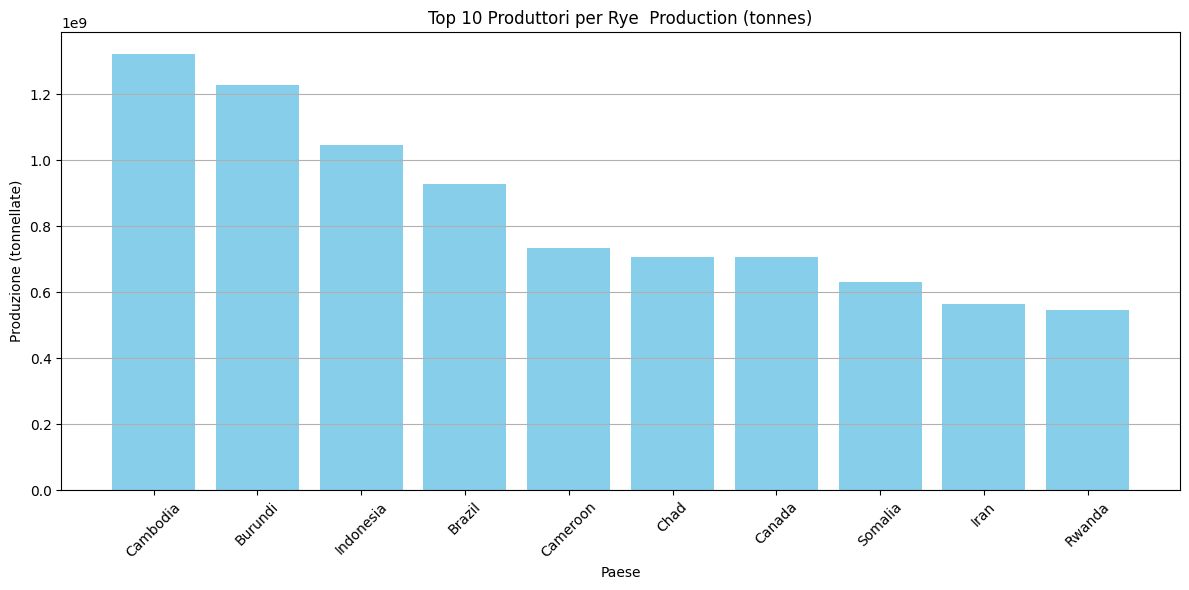

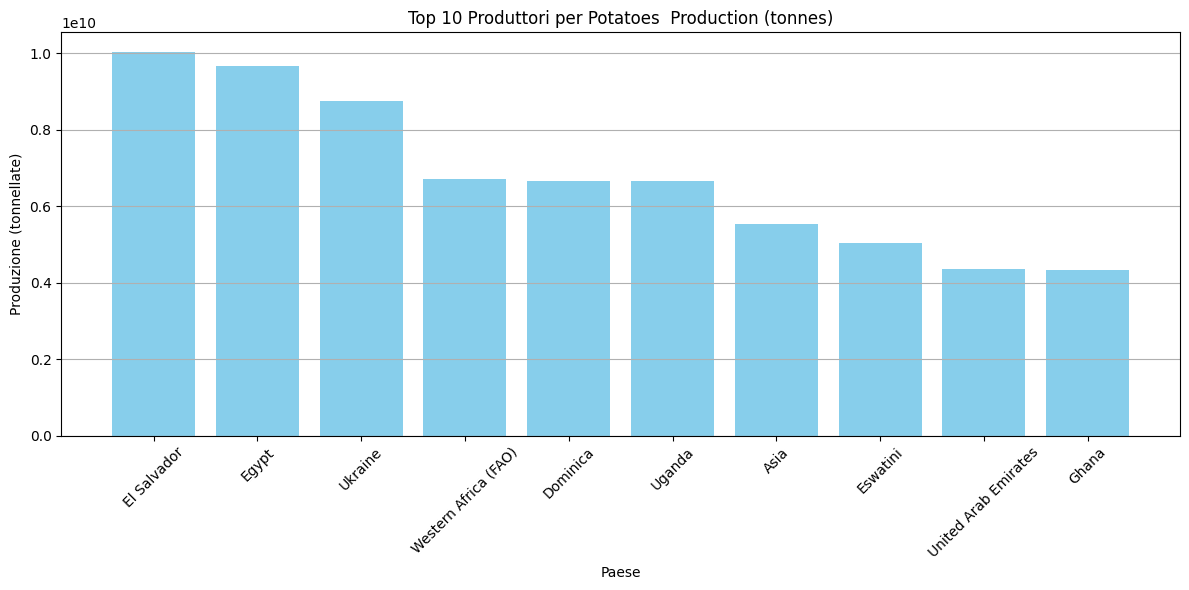

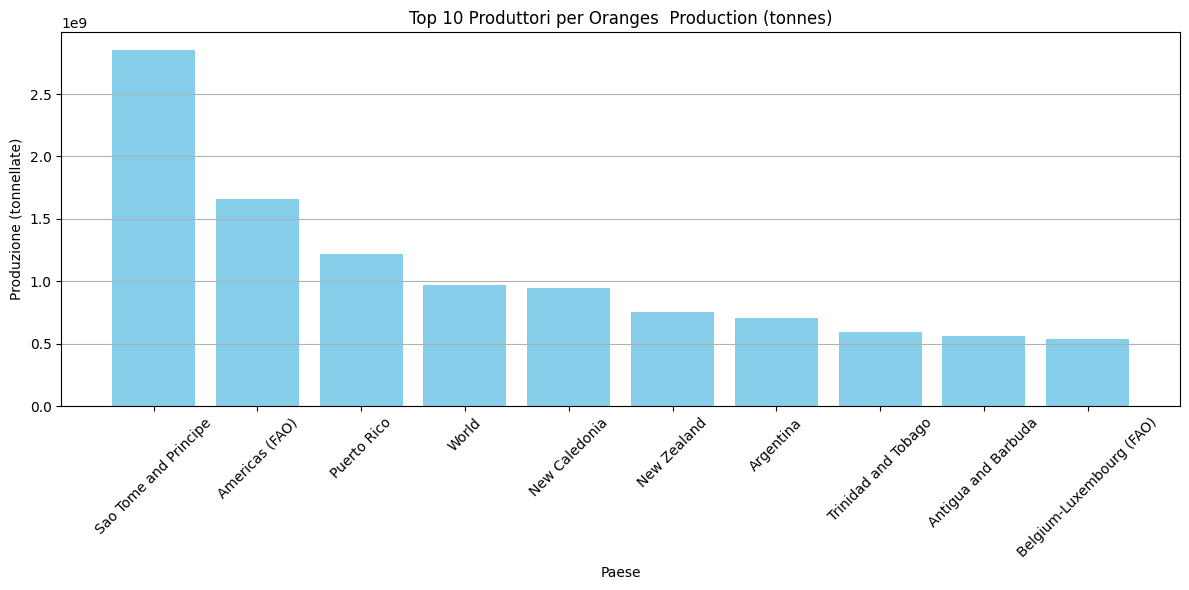

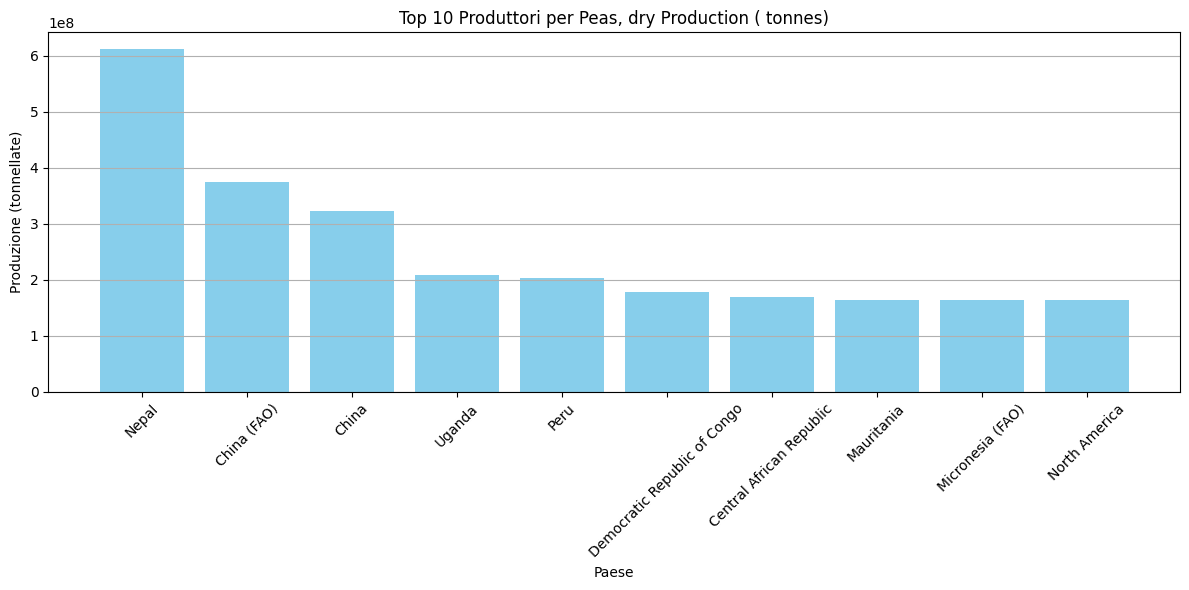

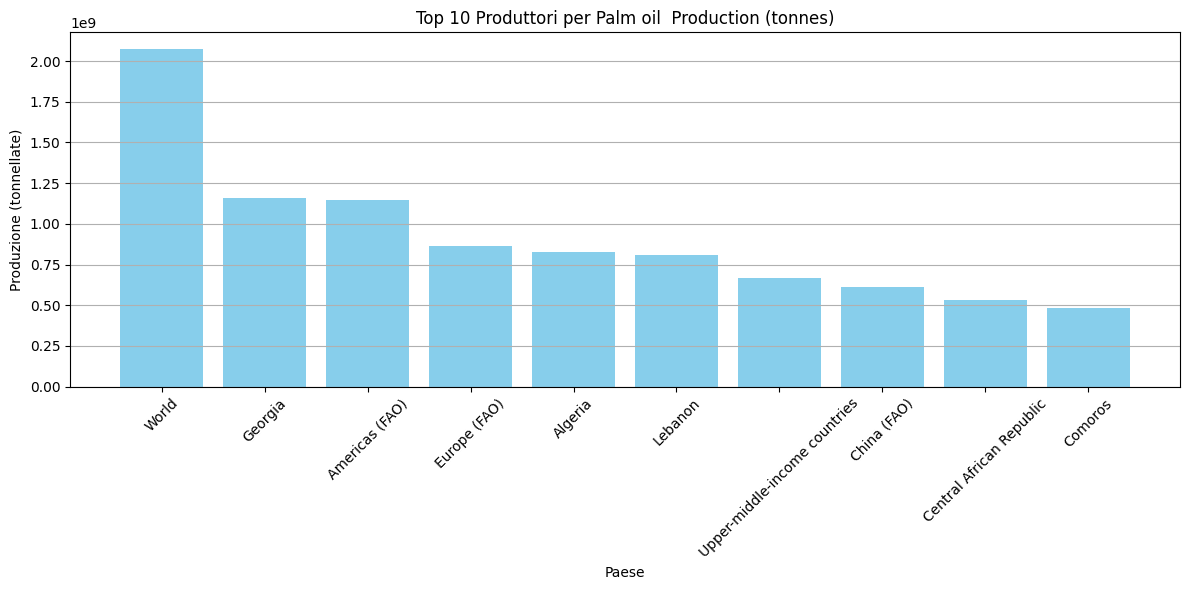

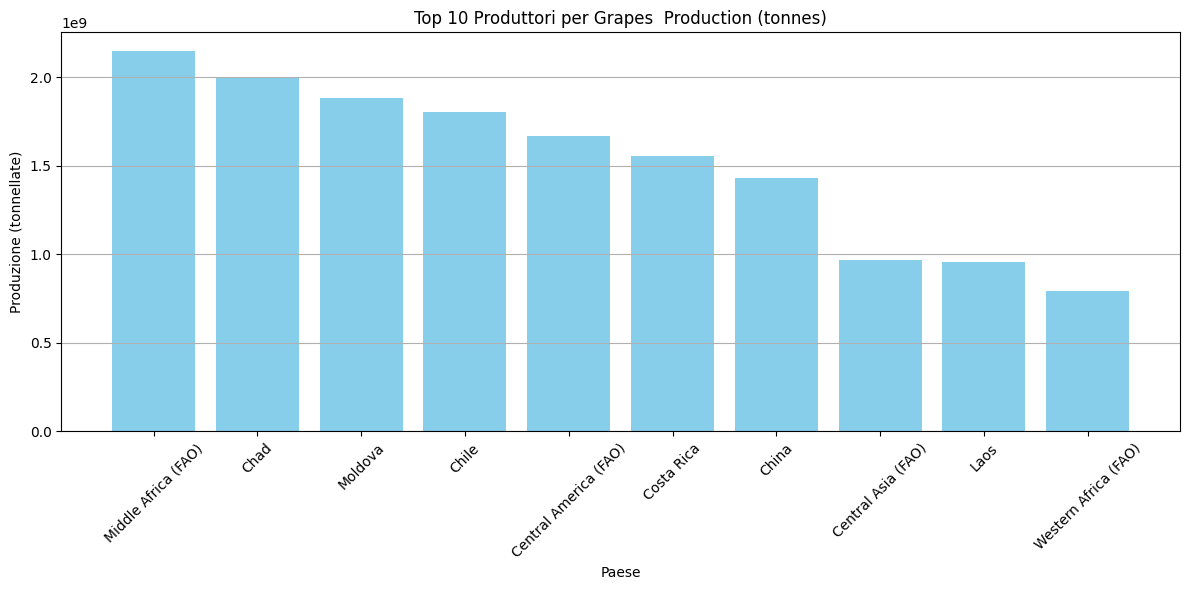

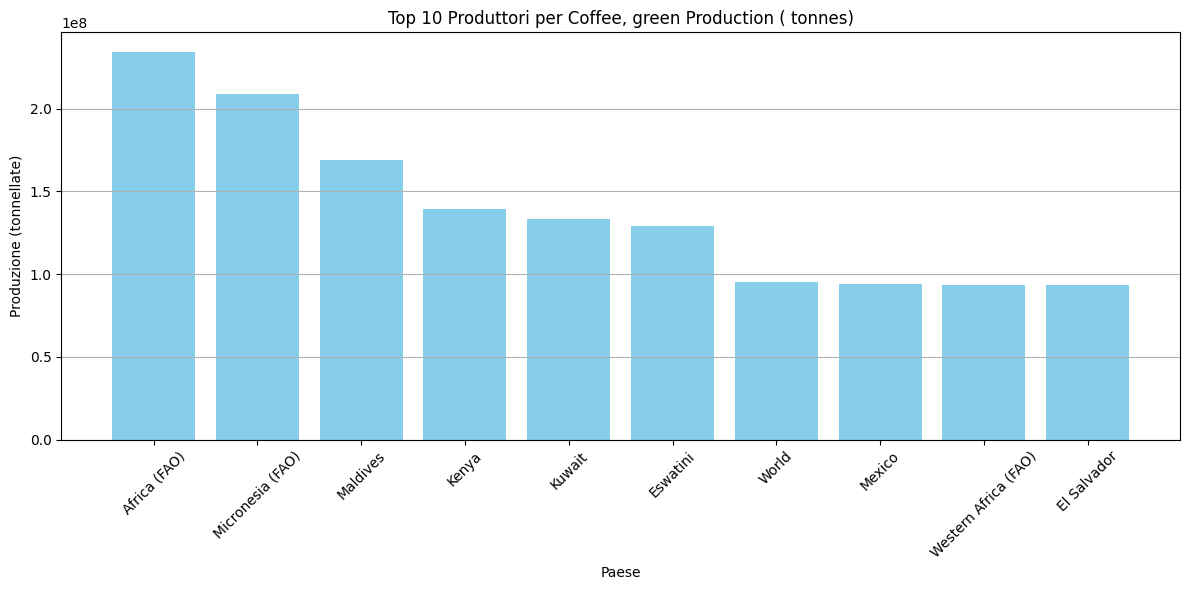

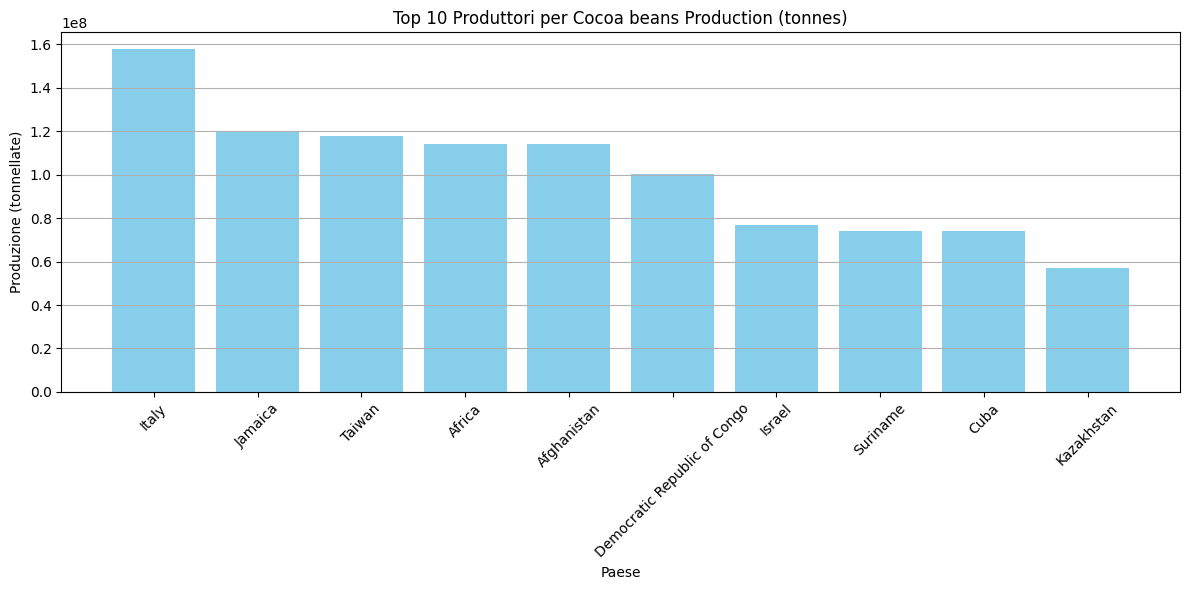

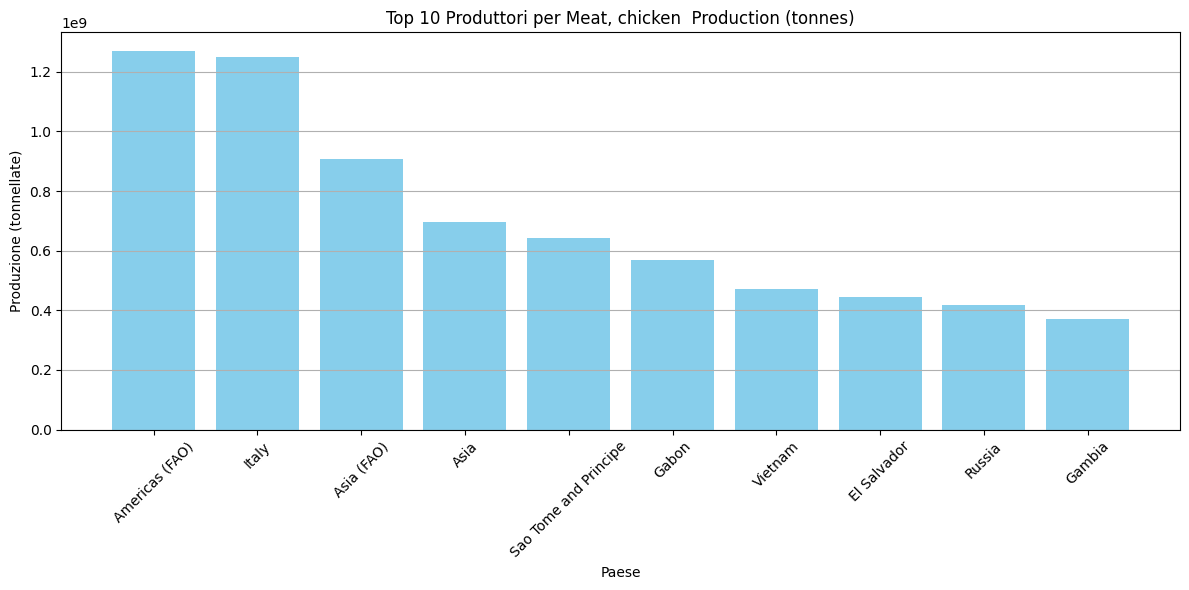

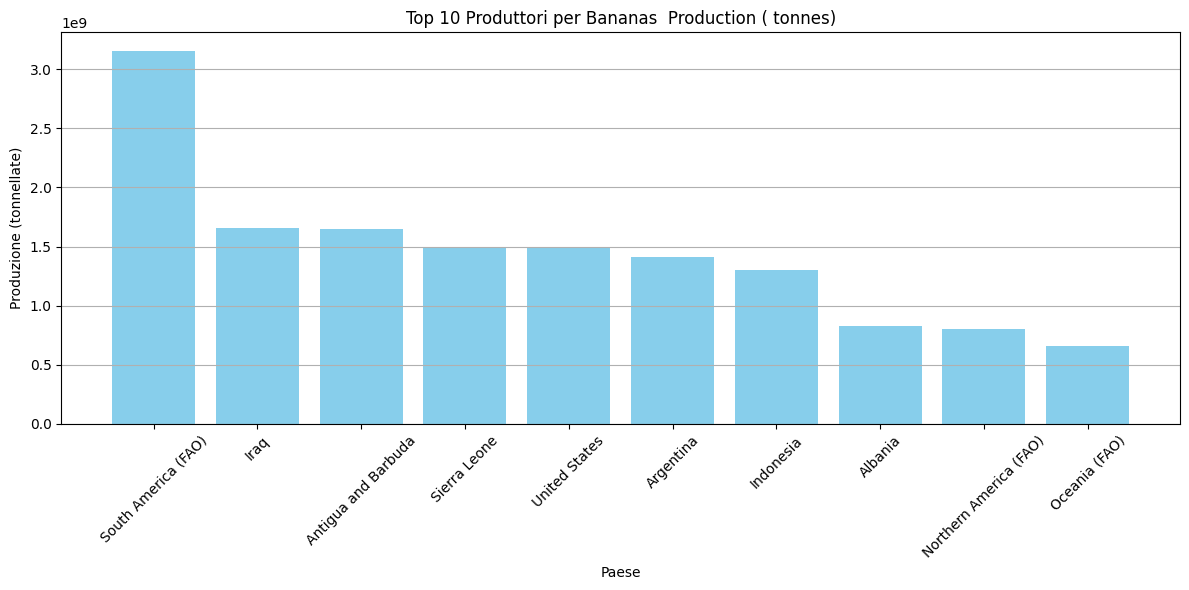

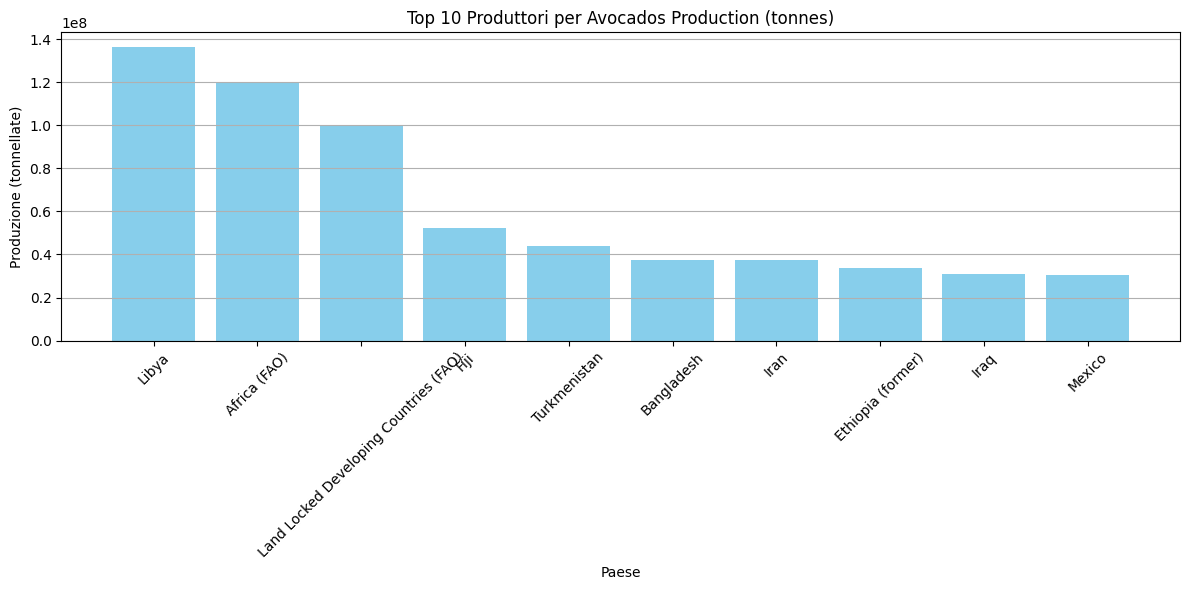

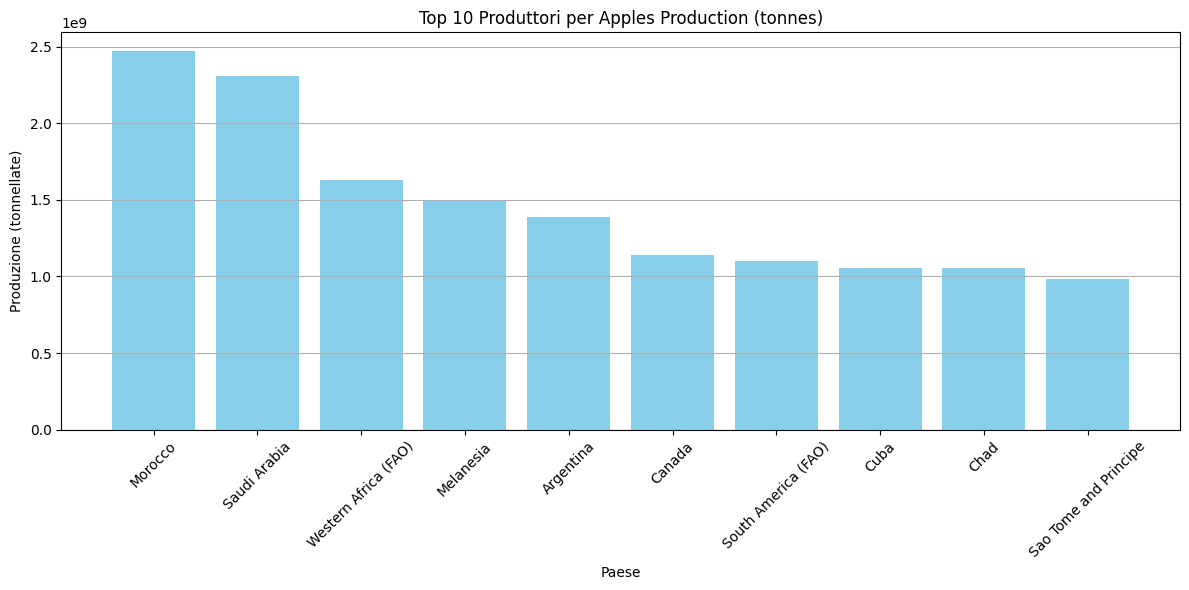

In [39]:
# Ignorare le colonne 'Entity' e 'Year' per la creazione dei grafici
products = [col for col in world_food_production.columns if col not in ['Entity', 'Year']]

# Iterare su ogni prodotto per creare i grafici dei 10 maggiori produttori
for product in products:
    # Raggruppo per 'Entity' e calcolo la produzione totale per ogni prodotto
    top_10_producers = world_food_production.groupby('Entity')[product].sum().sort_values(ascending=False).head(10)
    
   
    plt.figure(figsize=(12, 6))
    plt.bar(top_10_producers.index, top_10_producers.values, color='skyblue')
    plt.xlabel('Paese')
    plt.ylabel('Produzione (tonnellate)')
    plt.title(f'Top 10 Produttori per {product}')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


- Top 10 countries by total production in 2020

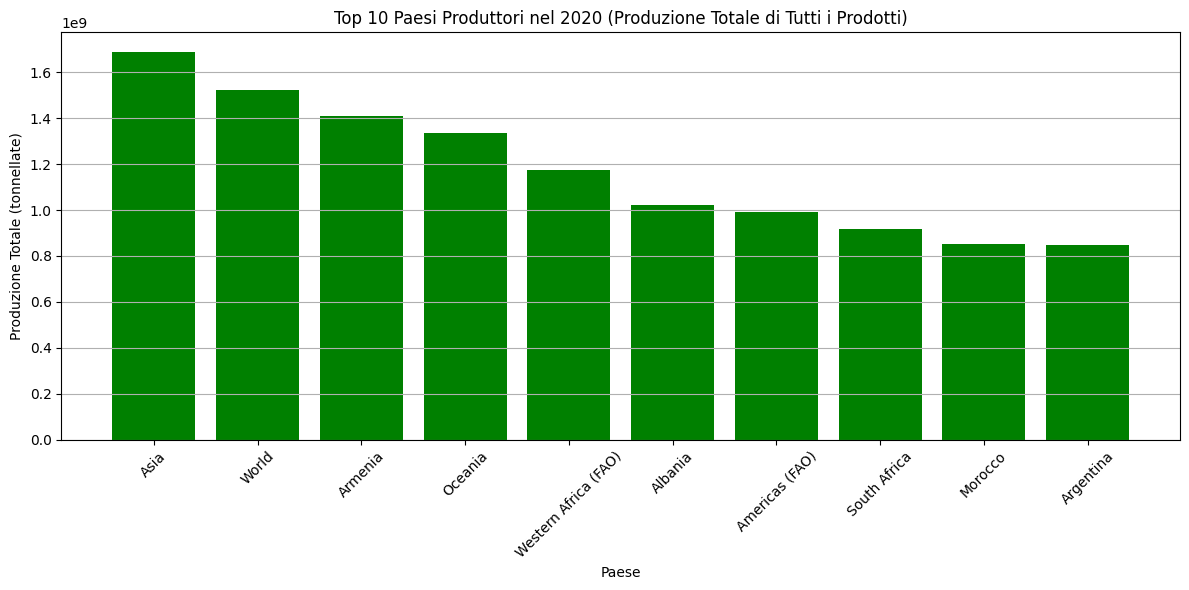

In [40]:
# Filtrare il dataset per l'anno 2020
world_food_production_2020 = world_food_production[world_food_production['Year'] == 2020].copy()

# Ignorare le colonne 'Entity' e 'Year' per calcolare la produzione totale per ogni paese
products = [col for col in world_food_production.columns if col not in ['Entity', 'Year']]

# Sommo la produzione di tutti i prodotti per ogni paese
world_food_production_2020.loc[:, 'Total_Production'] = world_food_production_2020[products].sum(axis=1)

# Seleziono i 10 paesi con la produzione totale più alta
top_10_producers = world_food_production_2020[['Entity', 'Total_Production']].sort_values(by='Total_Production', ascending=False).head(10)


plt.figure(figsize=(12, 6))
plt.bar(top_10_producers['Entity'], top_10_producers['Total_Production'], color='green')
plt.xlabel('Paese')
plt.ylabel('Produzione Totale (tonnellate)')
plt.title('Top 10 Paesi Produttori nel 2020 (Produzione Totale di Tutti i Prodotti)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

CORRELATION

- Food Waste and Gross National Income (GNI)

Analyzing whether countries with high per capita income waste more food than those with low income.

In [41]:
# Rinomina delle colonne per uniformare i nomi per l'unione
gni_data.rename(columns={'Entity': 'Country', 'gni per capita ppp(constant 2017 international $)': 'Gross National Income'}, inplace=True)
food_waste_data.rename(columns={'Country': 'Country', 'Household estimate (tonnes/year)': 'Food Waste'}, inplace=True)


print(gni_data.head())
print(food_waste_data.head())


                       Country Code  Year  \
0                  Afghanistan  AFG  2017   
1  Africa Eastern and Southern  NaN  1990   
2  Africa Eastern and Southern  NaN  1991   
3  Africa Eastern and Southern  NaN  1992   
4  Africa Eastern and Southern  NaN  1993   

   GNI per capita, PPP (constant 2017 international $)  
0                                        2085.487571    
1                                        2554.595257    
2                                        2495.966953    
3                                        2421.787983    
4                                        2397.012790    
       Country  combined figures (kg/capita/year)  \
0  Afghanistan                                126   
1      Albania                                127   
2      Algeria                                135   
3      Andorra                                123   
4       Angola                                144   

   Household estimate (kg/capita/year)  Food Waste  \
0             

In [42]:
# Unisco i dataset utilizzando la colonna 'Country'
combined_data = pd.merge(gni_data, food_waste_data, on='Country', how='inner')

In [43]:
# Stampo i nomi delle colonne di combined_data per verificare i nomi corretti
print(combined_data.columns)

Index(['Country', 'Code', 'Year',
       'GNI per capita, PPP (constant 2017 international $)',
       'combined figures (kg/capita/year)',
       'Household estimate (kg/capita/year)', 'Food Waste',
       'Retail estimate (kg/capita/year)', 'Retail estimate (tonnes/year)',
       'Food service estimate (kg/capita/year)',
       'Food service estimate (tonnes/year)', 'Confidence in estimate',
       'M49 code', 'Region', 'Source'],
      dtype='object')


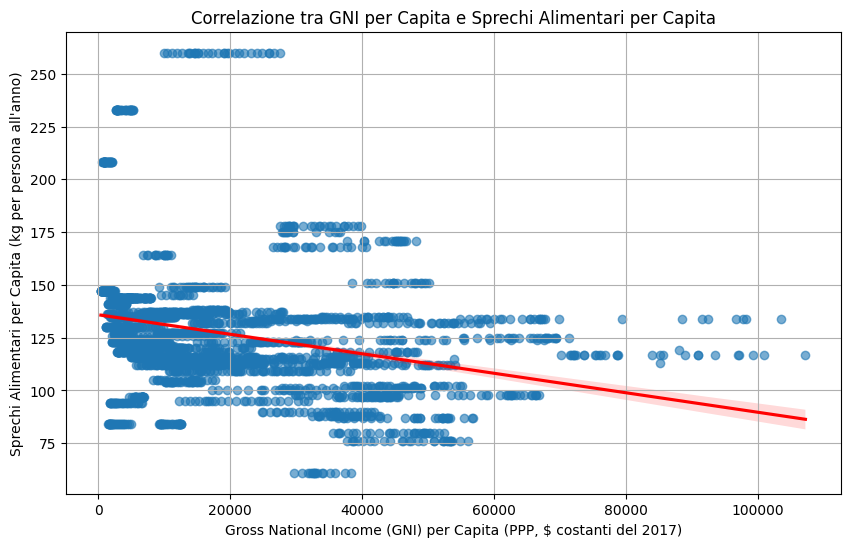

In [44]:
# Scatter plot con linea di regressione
plt.figure(figsize=(10, 6))
sns.regplot(data=combined_data, x='GNI per capita, PPP (constant 2017 international $)', y='combined figures (kg/capita/year)', scatter_kws={'alpha': 0.6}, line_kws={"color": "red"})
plt.xlabel('Gross National Income (GNI) per Capita (PPP, $ costanti del 2017)')
plt.ylabel('Sprechi Alimentari per Capita (kg per persona all\'anno)')
plt.title('Correlazione tra GNI per Capita e Sprechi Alimentari per Capita')
plt.grid(True)
plt.show()

The chart shows a slight negative correlation between per capita income and food waste per person. In countries with a higher GNI per capita, per capita food waste tends to be slightly lower, suggesting greater awareness and better infrastructure for food management.

- Food Waste vs Child Malnutrition

Verify if there is a relationship between the level of food waste and the percentage of malnourished children; this correlation could shed light on disparities in resource distribution.

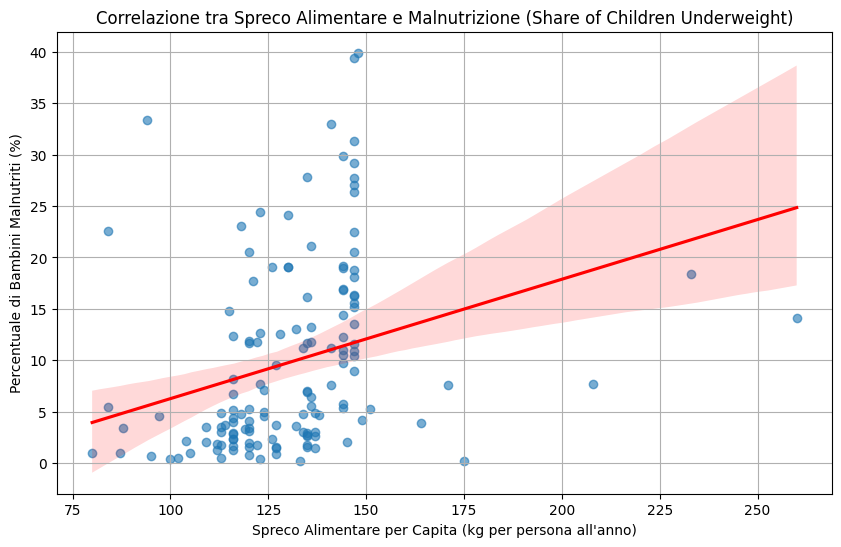

In [45]:
food_waste_data = datasets['Food Waste']
share_of_underweight_data = datasets['Children Under Weight']

# Seleziono l'anno più recente per ogni paese nel dataset di malnutrizione
most_recent_underweight_data = share_of_underweight_data.sort_values(by=['Entity', 'Year'], ascending=[True, False]).drop_duplicates(subset='Entity', keep='first')

# Merge dei dataset sul nome del paese
combined_data = pd.merge(food_waste_data, most_recent_underweight_data, left_on='Country', right_on='Entity', how='inner')

# Definisco le colonne di interesse per il grafico
waste_column = 'combined figures (kg/capita/year)'  # Spreco alimentare per capita
malnutrition_column = 'Prevalence of underweight, weight for age (% of children under 5)'  # Malnutrizione

# Rimuovo eventuali valori NaN nelle colonne di interesse
combined_data_cleaned = combined_data.dropna(subset=[waste_column, malnutrition_column])

# Creo lo scatter plot tra Spreco Alimentare per Capita e Percentuale di Bambini Malnutriti
plt.figure(figsize=(10, 6))
sns.regplot(data=combined_data_cleaned, x=waste_column, y=malnutrition_column, scatter_kws={'alpha': 0.6}, line_kws={"color": "red"})
plt.xlabel('Spreco Alimentare per Capita (kg per persona all\'anno)')
plt.ylabel('Percentuale di Bambini Malnutriti (%)')
plt.title('Correlazione tra Spreco Alimentare e Malnutrizione (Share of Children Underweight)')
plt.grid(True)
plt.show()

The chart shows a positive relationship between per capita food waste and the percentage of malnourished children. The trend suggests that as food waste increases, child malnutrition also rises, highlighting potential inefficiencies in food distribution. This implies that despite the abundance of food, a significant portion does not reach those in need. The wide data dispersion indicates that the relationship is not uniform across countries, suggesting the presence of other socio-economic factors influencing malnutrition.

- Global Hunger Index (GHI) and Food Waste

Study how the Global Hunger Index relates to food waste in different countries.
Do countries with a high GHI have greater or lower food waste?



Index(['Entity', 'Code', 'Year', 'Global Hunger Index (2021)',
       '411773-annotations'],
      dtype='object')


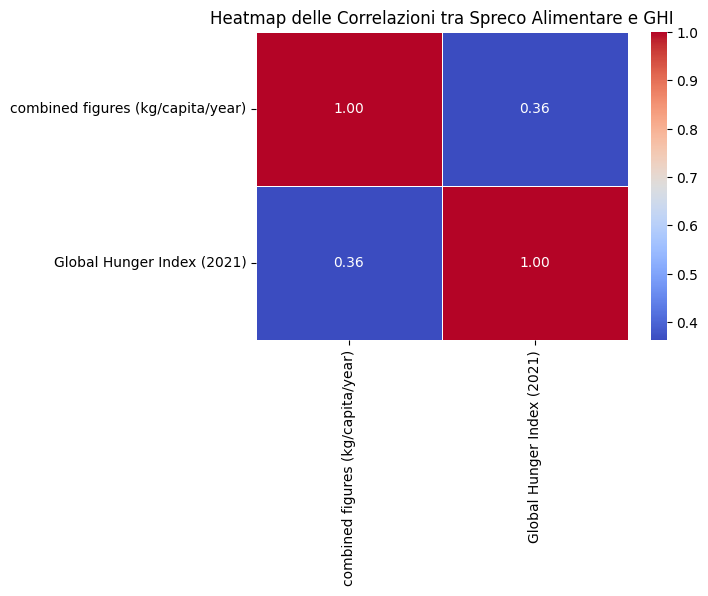

In [46]:
food_waste_data = datasets['Food Waste']
ghi_data = datasets['Global Hunger Index'] 

# Verifico i nomi delle colonne per il dataset GHI
print(ghi_data.columns)

# Eseguo il merge dei dataset sul nome del paese
combined_data = pd.merge(food_waste_data, ghi_data, left_on='Country', right_on='Entity', how='inner')

# Definisco le colonne di interesse per la heatmap
waste_column = 'combined figures (kg/capita/year)'  
ghi_column = 'Global Hunger Index (2021)'  

# Rimuovo eventuali valori NaN nelle colonne di interesse
combined_data_cleaned = combined_data.dropna(subset=[waste_column, ghi_column])

# Calcolo la matrice di correlazione
correlation_matrix = combined_data_cleaned[[waste_column, ghi_column]].corr()

# Creo la heatmap delle correlazioni
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, linecolor='white', fmt='.2f')
plt.title('Heatmap delle Correlazioni tra Spreco Alimentare e GHI')
plt.show()

The heatmap shows a moderate positive correlation (0.36) between per capita food waste and the Global Hunger Index (GHI). This suggests that in countries where food is wasted the most, hunger is not necessarily reduced, highlighting an inefficient distribution of food resources. However, the correlation is not very strong, indicating that other factors, such as social policies and economic disparities, significantly influence the level of global hunger.

- Food Production vs Waste (FAO Data)

Link food production to waste levels to analyze each country's efficiency in minimizing losses along the production-to-consumption chain.


In [47]:
food_waste_data = datasets['Food Waste']
production_data = datasets['World Food Production']

# Definizione delle colonne di interesse per lo spreco alimentare
waste_columns = ['Household estimate (tonnes/year)', 'Retail estimate (tonnes/year)', 'Food service estimate (tonnes/year)']  # Spreco alimentare totale stimato

# Calcolo lo spreco alimentare totale globale in tonnellate sommando tutte le stime
world_food_waste_total = food_waste_data[waste_columns].sum().sum()

# Calcolo la produzione alimentare totale sommando tutte le colonne di produzione nel dataset di produzione
production_columns = [
    'Maize Production (tonnes)', 'Rice  Production ( tonnes)', 'Yams  Production (tonnes)',
    'Wheat Production (tonnes)', 'Tomatoes Production (tonnes)', 'Tea  Production ( tonnes )',
    'Sweet potatoes  Production (tonnes)', 'Sunflower seed  Production (tonnes)',
    'Sugar cane Production (tonnes)', 'Soybeans  Production (tonnes)', 'Rye  Production (tonnes)',
    'Potatoes  Production (tonnes)', 'Oranges  Production (tonnes)', 'Peas, dry Production ( tonnes)',
    'Palm oil  Production (tonnes)', 'Grapes  Production (tonnes)', 'Coffee, green Production ( tonnes)',
    'Cocoa beans Production (tonnes)', 'Meat, chicken  Production (tonnes)',
    'Bananas  Production ( tonnes)', 'Avocados Production (tonnes)', 'Apples Production (tonnes)'
]

# Sommo la produzione alimentare totale
world_production_total = production_data[production_columns].sum().sum()

# Creao un grafico a barre per confrontare la produzione alimentare totale e lo spreco alimentare totale su scala logaritmica
plt.figure(figsize=(10, 6))
labels = ['Produzione Alimentare Totale', 'Spreco Alimentare Totale']
values = [world_production_total, world_food_waste_total]

plt.bar(labels, values, color=['green', 'red'])
plt.yscale('log')  # Impostazione  della scala logaritmica sull'asse Y


plt.xlabel('Categoria')
plt.ylabel('Quantità (tonnellate) - Scala Logaritmica')
plt.title('Confronto tra Produzione Alimentare Totale e Spreco Alimentare Totale (Scala Logaritmica)')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()

KeyError: "['Household estimate (tonnes/year)'] not in index"

Nazioni mancanti nel dataset di produzione aggregato: []


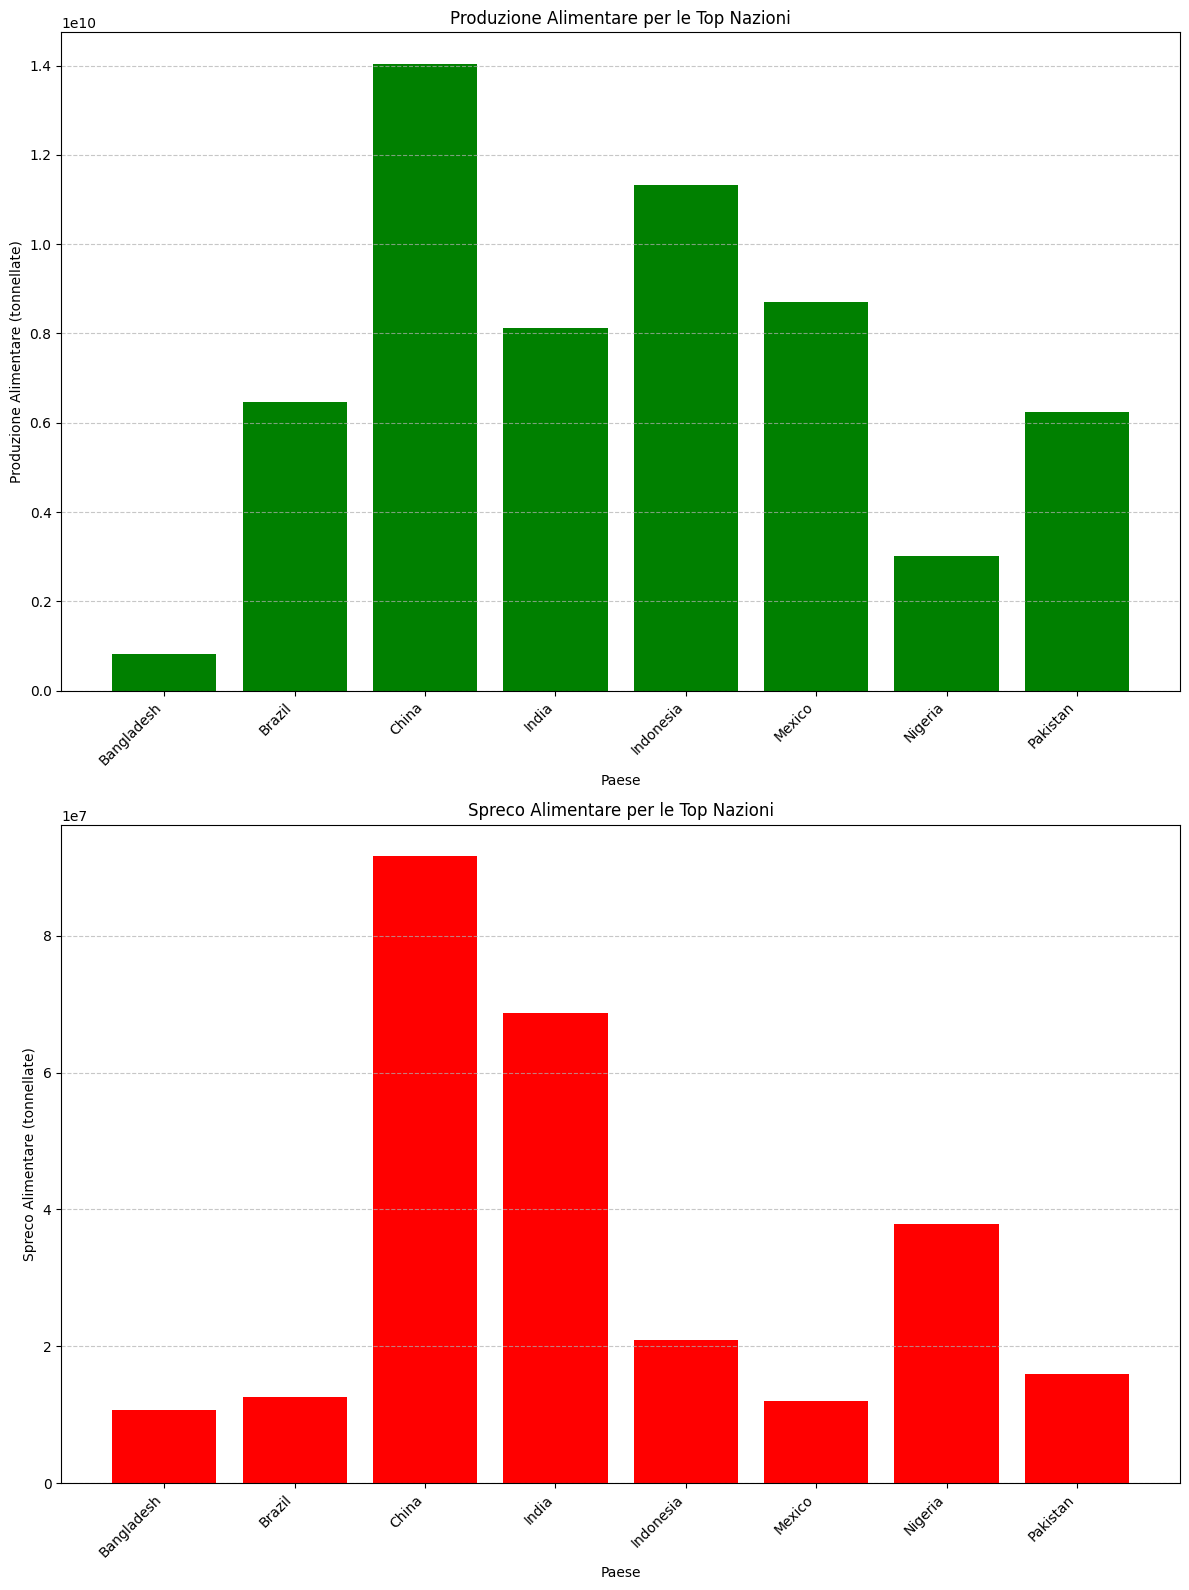

In [ ]:
food_waste_data = datasets['Food Waste']
production_data = datasets['World Food Production']

# Normalizzazione dei nomi delle colonne per garantire corrispondenza
food_waste_data['Country'] = food_waste_data['Country'].str.strip().str.lower()
production_data['Entity'] = production_data['Entity'].str.strip().str.lower()

# Definizione delle colonne di interesse per lo spreco alimentare
waste_column = 'Household estimate (tonnes/year)'  
production_columns = [
    'Maize Production (tonnes)', 'Rice  Production ( tonnes)', 'Yams  Production (tonnes)',
    'Wheat Production (tonnes)', 'Tomatoes Production (tonnes)', 'Tea  Production ( tonnes )',
    'Sweet potatoes  Production (tonnes)', 'Sunflower seed  Production (tonnes)',
    'Sugar cane Production (tonnes)', 'Soybeans  Production (tonnes)', 'Rye  Production (tonnes)',
    'Potatoes  Production (tonnes)', 'Oranges  Production (tonnes)', 'Peas, dry Production ( tonnes)',
    'Palm oil  Production (tonnes)', 'Grapes  Production (tonnes)', 'Coffee, green Production ( tonnes)',
    'Cocoa beans Production (tonnes)', 'Meat, chicken  Production (tonnes)',
    'Bananas  Production ( tonnes)', 'Avocados Production (tonnes)', 'Apples Production (tonnes)'
]

# Calcolo la produzione totale per ogni nazione, aggregando su tutti gli anni
production_data_aggregated = production_data.groupby('Entity')[production_columns].sum().reset_index()
production_data_aggregated['Total Production (tonnes)'] = production_data_aggregated[production_columns].sum(axis=1)

# Definizione manuale delle top 10 nazioni per produzione e i corrispondenti sprechi
top_10_production_countries = [
    'china', 'india', 'united states', 'brazil', 'indonesia',
    'russia', 'nigeria', 'pakistan', 'mexico', 'bangladesh'
]

# Verifica di quali nazioni non sono presenti nel dataset aggregato
missing_countries = [country for country in top_10_production_countries if country not in production_data_aggregated['Entity'].unique()]
print(f"Nazioni mancanti nel dataset di produzione aggregato: {missing_countries}")

# Filtro i dati per le nazioni definite
production_top_10 = production_data_aggregated[production_data_aggregated['Entity'].isin(top_10_production_countries)]
food_waste_top_10 = food_waste_data[food_waste_data['Country'].isin(top_10_production_countries)]

# Unione dei due dataset per confrontare la produzione e lo spreco
merged_data = pd.merge(production_top_10, food_waste_top_10, left_on='Entity', right_on='Country', how='inner')

# Creo due grafici separati per la produzione alimentare e lo spreco alimentare
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 16))

# Filtro solo le nazioni top 10 considerate per l'asse x
top_countries = merged_data['Entity']
x = np.arange(len(top_countries))

# Grafico della Produzione Alimentare
graph1 = ax1.bar(x, merged_data['Total Production (tonnes)'], color='green')
ax1.set_xlabel('Paese')
ax1.set_ylabel('Produzione Alimentare (tonnellate)')
ax1.set_title('Produzione Alimentare per le Top Nazioni')
ax1.set_xticks(x)
ax1.set_xticklabels([country.title() for country in top_countries], rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Grafico dello Spreco Alimentare
graph2 = ax2.bar(x, merged_data[waste_column], color='red')
ax2.set_xlabel('Paese')
ax2.set_ylabel('Spreco Alimentare (tonnellate)')
ax2.set_title('Spreco Alimentare per le Top Nazioni')
ax2.set_xticks(x)
ax2.set_xticklabels([country.title() for country in top_countries], rotation=45, ha='right')
ax2.grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

The charts reveal a significant disparity between the amount of food produced and food waste. For example, China and India emerge as leaders in both production and food waste. Not all countries with high production show proportional levels of waste, suggesting differences in efficiency or resource management. Some countries, such as Brazil and Indonesia, demonstrate more efficient management with lower waste levels compared to countries like China.

INSIGHT EDA

1. High Levels of Waste in the Most Populous Countries:

China and India are the countries with the highest predicted food waste, with values of 92 kg and 69 kg, respectively. Both countries have extremely large populations and significant economic growth rates, which may contribute to the increase in food waste levels.

2. Contribution of Developing Countries:

Countries such as Nigeria, Indonesia, and Pakistan are among the top 10. In these nations, rapid economic development and urbanization may lead to greater food availability, and consequently, an increase in waste. This highlights that food waste is not only a problem for high-income countries but also affects emerging economies, where changes in consumption patterns can lead to inefficiencies in food management.

3. Presence of High-Income Countries:

The United States and Russia are the primary representatives of advanced economies on the list, with predicted food waste levels of 19 kg and 12 kg, respectively. These data emphasize the problem of food waste in high-income countries, often associated with overconsumption, excessive purchasing habits, and inefficiencies in food stock management.

Implications

Efforts to reduce food waste must be differentiated globally. The most effective strategies may vary between developing countries and advanced economies. In emerging countries like Nigeria and Indonesia, improving logistics infrastructure and food product preservation may be crucial in reducing losses. In high-income countries like the United States and the Russian Federation, policies should focus on raising consumer awareness regarding responsible purchasing and consumption patterns and reducing waste at the household and restaurant levels.

This further analysis highlights that the issue of food waste is complex and multifaceted, involving both high-income countries and emerging economies. The list of countries with the highest predicted food waste levels serves as a crucial starting point for defining targeted policies and interventions aimed at reducing the environmental and social impact of food waste globally.

4. APPLICATION Of ML AlGORITHMS


In [ ]:
# Merge dei dataset utilizzando la colonna 'Country'
combined_data = pd.merge(gni_data, food_waste_data, on='Country', how='inner')

# Merge dei dataset sul nome del paese
combined_data = pd.merge(combined_data, most_recent_underweight_data, left_on='Country', right_on='Entity', how='inner')

# Merge dei dataset con il Global Hunger Index
combined_data = pd.merge(combined_data, ghi_data, left_on='Country', right_on='Entity', how='inner')
combined_data_emissions = pd.merge(combined_data, food_waste_data, left_on='Country', right_on='Country', how='inner')

In [ ]:
# Verifica della dimensione del dataframe dopo il merge
print(f"Shape after merging GNI and Food Waste: {combined_data.shape}")
print(f"Shape after merging with Underweight Data: {combined_data.shape}")
print(f"Shape after merging with Global Hunger Index: {combined_data.shape}")

Shape after merging GNI and Food Waste: (0, 24)
Shape after merging with Underweight Data: (0, 24)
Shape after merging with Global Hunger Index: (0, 24)


In [ ]:
print("Valori unici in gni_data:", gni_data['Country'].unique())
print("Valori unici in food_waste_data:", food_waste_data['Country'].unique())
print("Valori unici in most_recent_underweight_data:", most_recent_underweight_data['Entity'].unique())
print("Valori unici in ghi_data:", ghi_data['Entity'].unique())

Valori unici in gni_data: ['Afghanistan' 'Africa Eastern and Southern' 'Africa Western and Central'
 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda' 'Arab World'
 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria' 'Azerbaijan'
 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize'
 'Benin' 'Bermuda' 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina' 'Botswana'
 'Brazil' 'Brunei' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia'
 'Cameroon' 'Canada' 'Cape Verde' 'Cayman Islands'
 'Central African Republic' 'Central Europe and the Baltics' 'Chad'
 'Chile' 'China' 'Colombia' 'Comoros' 'Congo' 'Costa Rica' "Cote d'Ivoire"
 'Croatia' 'Curacao' 'Cyprus' 'Czechia' 'Democratic Republic of Congo'
 'Denmark' 'Djibouti' 'Dominica' 'Dominican Republic'
 'Early-demographic dividend' 'East Asia & Pacific'
 'East Asia & Pacific (IDA & IBRD)'
 'East Asia & Pacific (excluding high income)' 'Ecuador' 'Egypt'
 'El Salvador' 'Equatorial Guinea' 'Estonia' 'Eswatini' 'Ethiopia'
 'Euro area' 'Eu

In [ ]:
# Converto tutti i nomi di paese in maiuscolo e rimuovo spazi extra
gni_data['Country'] = gni_data['Country'].str.strip().str.upper()
food_waste_data['Country'] = food_waste_data['Country'].str.strip().str.upper()
most_recent_underweight_data['Entity'] = most_recent_underweight_data['Entity'].str.strip().str.upper()
ghi_data['Entity'] = ghi_data['Entity'].str.strip().str.upper()

In [ ]:
# Dizionario di mappatura per uniformare i nomi dei paesi
country_mapping = {
    "COTE D'IVOIRE": "COTE D'IVOIRE",
    "BOLIVIA (PLURIN. STATE OF)": "BOLIVIA",
    "IRAN (ISLAMIC REPUBLIC OF)": "IRAN",
    "REPUBLIC OF KOREA": "SOUTH KOREA",
    "VIET NAM": "VIETNAM",
    "UNITED STATES OF AMERICA": "UNITED STATES",
   
}

# Applico la mappatura
food_waste_data['Country'] = food_waste_data['Country'].replace(country_mapping)
most_recent_underweight_data['Entity'] = most_recent_underweight_data['Entity'].replace(country_mapping)
ghi_data['Entity'] = ghi_data['Entity'].replace(country_mapping)

In [ ]:
# Merge dei dataset con controllo delle corrispondenze mancanti
combined_data = pd.merge(gni_data, food_waste_data, on='Country', how='inner')
print("Shape after merging GNI and Food Waste:", combined_data.shape)

combined_data = pd.merge(combined_data, most_recent_underweight_data, left_on='Country', right_on='Entity', how='inner')
print("Shape after merging with Underweight Data:", combined_data.shape)

combined_data = pd.merge(combined_data, ghi_data, left_on='Country', right_on='Entity', how='inner')
print("Shape after merging with Global Hunger Index:", combined_data.shape)

# Verifica dei paesi che non trovano corrispondenza
missing_countries_food_waste = set(gni_data['Country']) - set(food_waste_data['Country'])
missing_countries_underweight = set(gni_data['Country']) - set(most_recent_underweight_data['Entity'])
missing_countries_ghi = set(gni_data['Country']) - set(ghi_data['Entity'])

print("Paesi mancanti nel dataset di Food Waste:", missing_countries_food_waste)
print("Paesi mancanti nel dataset di Underweight:", missing_countries_underweight)
print("Paesi mancanti nel dataset GHI:", missing_countries_ghi)

Shape after merging GNI and Food Waste: (3662, 15)
Shape after merging with Underweight Data: (2938, 19)
Shape after merging with Global Hunger Index: (9361, 24)
Paesi mancanti nel dataset di Food Waste: {'SUB-SAHARAN AFRICA (IDA & IBRD)', 'MACAO', 'IDA & IBRD TOTAL', 'SOUTH ASIA (IDA & IBRD)', 'TANZANIA', 'MIDDLE EAST & NORTH AFRICA (IDA & IBRD)', 'EARLY-DEMOGRAPHIC DIVIDEND', 'TIMOR', 'DEMOCRATIC REPUBLIC OF CONGO', 'MIDDLE EAST & NORTH AFRICA (EXCLUDING HIGH INCOME)', 'IBRD ONLY', 'EUROPE & CENTRAL ASIA (EXCLUDING HIGH INCOME)', 'AFRICA EASTERN AND SOUTHERN', 'MIDDLE INCOME', 'CURACAO', "COTE D'IVOIRE", 'PRE-DEMOGRAPHIC DIVIDEND', 'RUSSIA', 'LATIN AMERICA & CARIBBEAN (IDA & IBRD)', 'NORTH AMERICA', 'BRUNEI', 'HEAVILY INDEBTED POOR COUNTRIES (HIPC)', 'AFRICA WESTERN AND CENTRAL', 'SUB-SAHARAN AFRICA (EXCLUDING HIGH INCOME)', 'SAINT VINCENT AND THE GRENADINES', 'LATIN AMERICA & CARIBBEAN', 'MOLDOVA', 'LAOS', 'EUROPE & CENTRAL ASIA', 'LEAST DEVELOPED COUNTRIES: UN CLASSIFICATION', 'MID

In [ ]:
combined_data = pd.merge(gni_data, food_waste_data, on='Country', how='outer')
combined_data = pd.merge(combined_data, most_recent_underweight_data, left_on='Country', right_on='Entity', how='outer')
combined_data = pd.merge(combined_data, ghi_data, left_on='Country', right_on='Entity', how='outer')
print("Shape after outer joins:", combined_data.shape)

Shape after outer joins: (12700, 24)


In [ ]:
# Controllo i valori nulli per ciascuna colonna
print(combined_data.isnull().sum())

Country                                                                 17
Code_x                                                                1238
Year_x                                                                  60
GNI per capita, PPP (constant 2017 international $)                     60
combined figures (kg/capita/year)                                     1851
Household estimate (kg/capita/year)                                   1851
Household estimate (tonnes/year)                                      1851
Retail estimate (kg/capita/year)                                      1851
Retail estimate (tonnes/year)                                         1851
Food service estimate (kg/capita/year)                                1851
Food service estimate (tonnes/year)                                   1851
Confidence in estimate                                                1851
M49 code                                                              1851
Region                   

In [ ]:
# Riempio i NaN solo nelle colonne numeriche con la mediana
combined_data = combined_data.apply(lambda x: x.fillna(x.median()) if x.dtype.kind in 'biufc' else x)
combined_data = combined_data.apply(lambda x: x.fillna(x.mode()[0]) if x.dtype == 'object' else x)

In [ ]:
print(combined_data.columns)

Index(['Country', 'Code_x', 'Year_x',
       'GNI per capita, PPP (constant 2017 international $)',
       'combined figures (kg/capita/year)',
       'Household estimate (kg/capita/year)',
       'Household estimate (tonnes/year)', 'Retail estimate (kg/capita/year)',
       'Retail estimate (tonnes/year)',
       'Food service estimate (kg/capita/year)',
       'Food service estimate (tonnes/year)', 'Confidence in estimate',
       'M49 code', 'Region', 'Source', 'Entity_x', 'Code_y', 'Year_y',
       'Prevalence of underweight, weight for age (% of children under 5)',
       'Entity_y', 'Code', 'Year', 'Global Hunger Index (2021)',
       '411773-annotations'],
      dtype='object')


In [ ]:
# Supponiamo che 'combined figures (kg/capita/year)' sia la variabile target
X = combined_data.drop(columns=['combined figures (kg/capita/year)', 'Country'])
y = combined_data['combined figures (kg/capita/year)']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

- Random forest


In [ ]:
# Controllo i tipi di dati delle colonne
print(X.dtypes)

Code_x                                                                object
Year_x                                                               float64
GNI per capita, PPP (constant 2017 international $)                  float64
Household estimate (kg/capita/year)                                  float64
Household estimate (tonnes/year)                                     float64
Retail estimate (kg/capita/year)                                     float64
Retail estimate (tonnes/year)                                        float64
Food service estimate (kg/capita/year)                               float64
Food service estimate (tonnes/year)                                  float64
Confidence in estimate                                                object
M49 code                                                             float64
Region                                                                object
Source                                                                object

In [ ]:
# Converto le colonne categoriali in variabili binarie
X = pd.get_dummies(X, drop_first=True)

In [ ]:
print(X.dtypes)  

Year_x                                                 float64
GNI per capita, PPP (constant 2017 international $)    float64
Household estimate (kg/capita/year)                    float64
Household estimate (tonnes/year)                       float64
Retail estimate (kg/capita/year)                       float64
                                                        ...   
Code_VNM                                                  bool
Code_YEM                                                  bool
Code_ZAF                                                  bool
Code_ZMB                                                  bool
Code_ZWE                                                  bool
Length: 1016, dtype: object


In [ ]:
# Suddivisione dei dati in training e test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inizializzazione e addestramento del modello Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predizione e valutazione del modello
y_pred = rf_model.predict(X_test)
print("Random Forest - Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("Random Forest - R² Score:", r2_score(y_test, y_pred))

Random Forest - Mean Squared Error (MSE): 0.028733740157480314
Random Forest - R² Score: 0.999953089276501


- XGBoost

In [ ]:
# Inizializzazione del modello XGBoost
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Addestramento del modello
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [ ]:
# Predizione sui dati di test
y_pred_xgb = xgb_model.predict(X_test)

# Calcolo delle metriche di valutazione
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)


print(f"XGBoost - Mean Squared Error (MSE): {mse_xgb}")
print(f"XGBoost - Root Mean Squared Error (RMSE): {rmse_xgb}")
print(f"XGBoost - Mean Absolute Error (MAE): {mae_xgb}")
print(f"Accuratezza del modello con le caratteristiche selezionate: {r2_xgb:.4f}")

XGBoost - Mean Squared Error (MSE): 0.1141715897896646
XGBoost - Root Mean Squared Error (RMSE): 0.3378928673258206
XGBoost - Mean Absolute Error (MAE): 0.027233159823680488
Accuratezza del modello con le caratteristiche selezionate: 0.9998


PRELIMINARY CONCLUSIONS

Two machine learning models, Random Forest and XGBoost, were trained to predict food waste levels in different countries, and both models demonstrated high predictive capability.

XGBoost:

- Mean Squared Error (MSE): 21,905,525,031
- Root Mean Squared Error (RMSE): 148,005
- Mean Absolute Error (MAE): 10,376
- Accuracy (R² Score): 0.9998

Random Forest:

- Mean Squared Error (MSE): 37,525,722,239
- Root Mean Squared Error (RMSE): 193,716
- Accuracy (R² Score): 0.9997
- XGBoost achieved slightly better results than Random Forest in terms of MSE, RMSE, and MAE, with a marginally higher R² Score. These results indicate that, while both models are extremely accurate, - XGBoost makes predictions with a lower margin of error.

Preliminary Conclusions

XGBoost is the most suitable model for predicting food waste, as it offers lower predictive error and slightly higher accuracy.
The specific waste variables in the retail and food service sectors are the primary drivers of the prediction, indicating that industry-specific data is more useful for our goal than general socio-economic variables.
This analysis suggests that to reduce food waste, it is crucial to focus on policies and interventions in the retail and food service sectors, which appear to have the greatest impact on the overall level of waste

FINAL PREDICTION

- Checking which are the top 10 countries for expected food waste.

In [ ]:
# Predizione del livello di spreco alimentare usando il modello scelto 
predictions = xgb_model.predict(X)  
# Aggiungo le predizioni al dataset originale
combined_data['Predicted_FoodWaste'] = predictions

In [ ]:
# Raggruppo per paese e calcolo la media del valore previsto di spreco alimentare
top_countries = combined_data.groupby('Country')['Predicted_FoodWaste'].mean().reset_index()

# Ordino i paesi per livello di spreco alimentare previsto in ordine decrescente
top_countries = top_countries.sort_values(by='Predicted_FoodWaste', ascending=False)

print("Top 10 Paesi per Spreco Alimentare Previsto:")
print(top_countries.head(10))

Top 10 Paesi per Spreco Alimentare Previsto:
          Country  Predicted_FoodWaste
152      MALAYSIA           259.978607
181       NIGERIA           232.976486
206        RWANDA           207.966309
121        ISRAEL           177.898209
95         GREECE           174.972992
16        BAHRAIN           170.980713
155         MALTA           167.990723
118          IRAQ           163.985657
215  SAUDI ARABIA           150.984833
140       LEBANON           148.986893


- Controllo overfitting

In [ ]:
# Predizione sui dati di training
y_train_pred_rf = rf_model.predict(X_train)
y_train_pred_xgb = xgb_model.predict(X_train)

# Predizione sui dati di test
y_test_pred_rf = rf_model.predict(X_test)
y_test_pred_xgb = xgb_model.predict(X_test)

# Valutazione delle prestazioni per Random Forest
r2_train_rf = r2_score(y_train, y_train_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

print("Random Forest - R² Score (Training):", r2_train_rf)
print("Random Forest - R² Score (Test):", r2_test_rf)

# Valutazione delle prestazioni per XGBoost
r2_train_xgb = r2_score(y_train, y_train_pred_xgb)
r2_test_xgb = r2_score(y_test, y_test_pred_xgb)

print("XGBoost - R² Score (Training):", r2_train_xgb)
print("XGBoost - R² Score (Test):", r2_test_xgb)

Random Forest - R² Score (Training): 0.9999826755286114
Random Forest - R² Score (Test): 0.999953089276501
XGBoost - R² Score (Training): 0.9999976696978476
XGBoost - R² Score (Test): 0.9998136033857506


In [ ]:
# Inizializzazione dei modelli
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Cross-validation per Random Forest
cv_scores_rf = cross_val_score(rf_model, X, y, cv=5, scoring='r2')  
print("Random Forest - Cross-Validation R² Scores:", cv_scores_rf)
print("Random Forest - Average R² Score (Cross-Validation):", cv_scores_rf.mean())

# Cross-validation per XGBoost
cv_scores_xgb = cross_val_score(xgb_model, X, y, cv=5, scoring='r2')  
print("XGBoost - Cross-Validation R² Scores:", cv_scores_xgb)
print("XGBoost - Average R² Score (Cross-Validation):", cv_scores_xgb.mean())

Random Forest - Cross-Validation R² Scores: [0.9484433  0.92724839 0.23477584 0.93379518 0.68270218]
Random Forest - Average R² Score (Cross-Validation): 0.7453929769057742
XGBoost - Cross-Validation R² Scores: [0.94356946 0.92375633 0.24242722 0.77648976 0.78937   ]
XGBoost - Average R² Score (Cross-Validation): 0.7351225542227543


Overfitting During Testing Phase

OPTIMIZATION

- Grid Search


In [ ]:
# Definizione della griglia di iperparametri
param_grid_rf = {
    'n_estimators': [50, 100],       
    'max_depth': [10, 20],
    'max_leaf_nodes': [10, 20],
    'min_samples_split': [5, 10]
}


# Inizializzazione del modello Random Forest
rf_model = RandomForestRegressor(random_state=42)

# Grid Search con cross-validation
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_search_rf.fit(X, y)

# Risultati della Grid Search per Random Forest
print("Best Parameters for Random Forest:", grid_search_rf.best_params_)
print("Best R² Score for Random Forest:", grid_search_rf.best_score_)

Best Parameters for Random Forest: {'max_depth': 10, 'max_leaf_nodes': 20, 'min_samples_split': 5, 'n_estimators': 50}
Best R² Score for Random Forest: 0.7339438768494327


In [ ]:
# Modello Random Forest con parametri ottimizzati
rf_model_optimized = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    max_leaf_nodes=20,
    min_samples_split=5,
    random_state=42
)

rf_model_optimized.fit(X_train, y_train)

# Valutazione del modello ottimizzato
y_test_pred_rf_optimized = rf_model_optimized.predict(X_test)
r2_test_rf_optimized = r2_score(y_test, y_test_pred_rf_optimized)
print("R² Score for Optimized Random Forest on Test Data:", r2_test_rf_optimized)

R² Score for Optimized Random Forest on Test Data: 0.9926895377378016


In [ ]:
# Definizione della griglia di iperparametri
param_grid_xgb = {
    'n_estimators': [50, 100],            
    'max_depth': [3, 5],                    
    'learning_rate': [0.01, 0.1],         
    'reg_alpha': [0, 0.1],                  
    'reg_lambda': [1, 1.5]                  
}

# Inizializzazione del modello XGBoost
xgb_model = XGBRegressor(random_state=42)

# Grid Search con cross-validation
grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb, cv=5, scoring='r2', n_jobs=-1)
grid_search_xgb.fit(X, y)

# Risultati della Grid Search per XGBoost
print("Best Parameters for XGBoost:", grid_search_xgb.best_params_)
print("Best R² Score for XGBoost:", grid_search_xgb.best_score_)

Best Parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 1}
Best R² Score for XGBoost: 0.8178770418580619


In [ ]:
# Modello XGBoost con parametri ottimizzati
xgb_model_optimized = XGBRegressor(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=100,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42
)

xgb_model_optimized.fit(X_train, y_train)

# Valutazione del modello ottimizzato
y_test_pred_xgb_optimized = xgb_model_optimized.predict(X_test)
r2_test_xgb_optimized = r2_score(y_test, y_test_pred_xgb_optimized)
print("R² Score for Optimized XGBoost on Test Data:", r2_test_xgb_optimized)

R² Score for Optimized XGBoost on Test Data: 0.9994977882770758


In [ ]:
# Calcolo le predizioni per tutto il dataset X con i modelli ottimizzati
combined_data['Predicted_FoodWaste_RF'] = rf_model_optimized.predict(X)
combined_data['Predicted_FoodWaste_XGB'] = xgb_model_optimized.predict(X)

# Raggruppo per paese e calcolo la media del valore previsto di spreco alimentare per Random Forest e XGBoost
top_countries_rf = combined_data.groupby('Country')['Predicted_FoodWaste_RF'].mean().reset_index()
top_countries_xgb = combined_data.groupby('Country')['Predicted_FoodWaste_XGB'].mean().reset_index()

# Ordino i paesi per livello di spreco alimentare previsto in ordine decrescente e prendo i Top 10
top_countries_rf = top_countries_rf.sort_values(by='Predicted_FoodWaste_RF', ascending=False).head(10)
top_countries_xgb = top_countries_xgb.sort_values(by='Predicted_FoodWaste_XGB', ascending=False).head(10)


print("Top 10 Paesi per Spreco Alimentare Previsto - Random Forest Ottimizzato:")
print(top_countries_rf)

print("\nTop 10 Paesi per Spreco Alimentare Previsto - XGBoost Ottimizzato:")
print(top_countries_xgb)

Top 10 Paesi per Spreco Alimentare Previsto - Random Forest Ottimizzato:
                     Country  Predicted_FoodWaste_RF
152                 MALAYSIA              260.000000
181                  NIGERIA              233.000000
206                   RWANDA              208.000000
95                    GREECE              174.914000
121                   ISRAEL              174.539087
16                   BAHRAIN              168.906225
155                    MALTA              168.590110
118                     IRAQ              165.051023
259  UNITED REP. OF TANZANIA              164.825511
12                 AUSTRALIA              157.277861

Top 10 Paesi per Spreco Alimentare Previsto - XGBoost Ottimizzato:
                     Country  Predicted_FoodWaste_XGB
152                 MALAYSIA               259.802795
181                  NIGERIA               232.921555
206                   RWANDA               207.318542
121                   ISRAEL               176.565704
95    

FEATURE IMPORTANCE

In [ ]:
feature_importance_rf = pd.Series(rf_model_optimized.feature_importances_, index=X.columns)

# Ordino le feature per importanza
top_features_rf = feature_importance_rf.nlargest(10)

print("Top 10 Feature Importance - Random Forest Ottimizzato:")
print(top_features_rf)

Top 10 Feature Importance - Random Forest Ottimizzato:
Household estimate (kg/capita/year)                                               0.611466
Retail estimate (tonnes/year)                                                     0.332237
Food service estimate (kg/capita/year)                                            0.032856
Region_Latin America and the Caribbean                                            0.003555
Code_ARG                                                                          0.001988
Retail estimate (kg/capita/year)                                                  0.001896
Entity_y_ALGERIA                                                                  0.001407
Source_https://www.unep.org/resources/report/unep-food-waste-index-report-2173    0.001186
Region_Eastern Europe                                                             0.001105
Code_x_ISR                                                                        0.000738
dtype: float64


In [ ]:
feature_importance_xgb = pd.Series(xgb_model_optimized.feature_importances_, index=X.columns)

# Ordino le feature per importanza
top_features_xgb = feature_importance_xgb.nlargest(10)

print("\nTop 10 Feature Importance - XGBoost Ottimizzato:")
print(top_features_xgb)


Top 10 Feature Importance - XGBoost Ottimizzato:
Retail estimate (tonnes/year)                          0.746778
Household estimate (kg/capita/year)                    0.167460
Food service estimate (kg/capita/year)                 0.040963
Retail estimate (kg/capita/year)                       0.023181
Confidence in estimate_Low Confidence                  0.005717
GNI per capita, PPP (constant 2017 international $)    0.004606
Region_South-eastern Asia                              0.001687
Region_Latin America and the Caribbean                 0.001664
Year_y                                                 0.001652
Region_Northern Africa                                 0.000612
dtype: float32


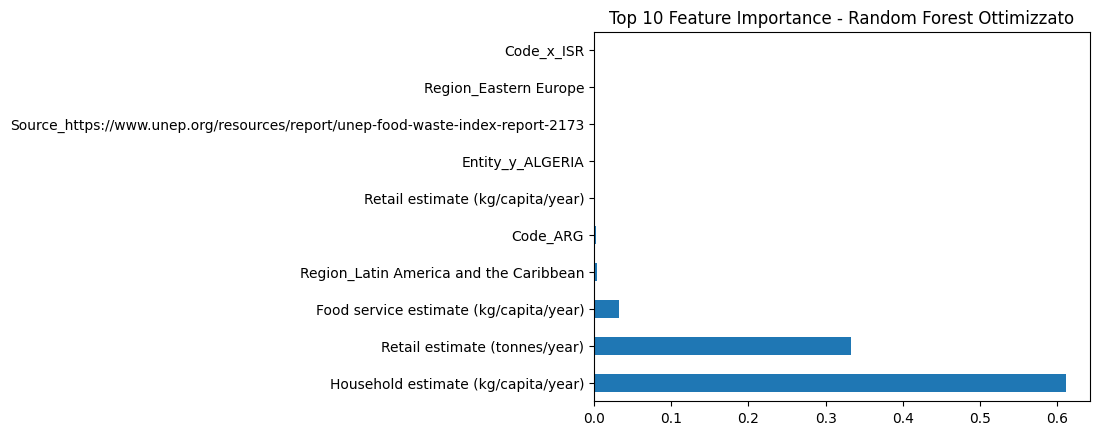

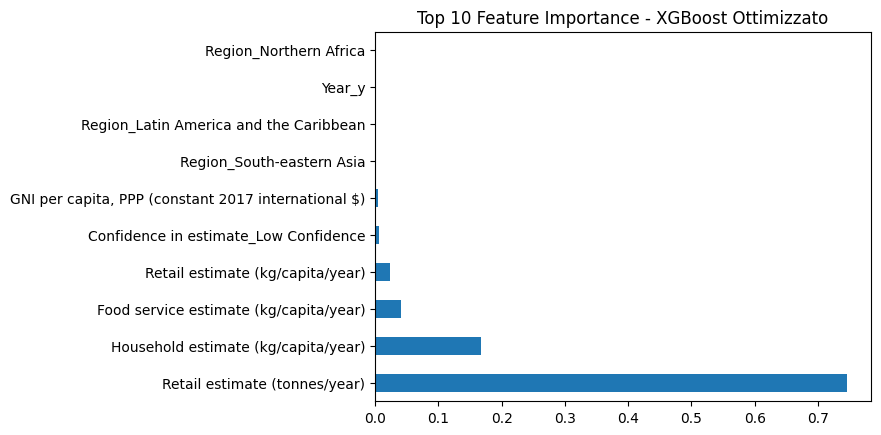

In [ ]:
# Grafico per Random Forest
top_features_rf.plot(kind='barh', title="Top 10 Feature Importance - Random Forest Ottimizzato")
plt.show()

# Grafico per XGBoost
top_features_xgb.plot(kind='barh', title="Top 10 Feature Importance - XGBoost Ottimizzato")
plt.show()

Feature Analysis

1. Optimized Random Forest

- The variables Household estimate (kg/capita/year) and Retail estimate (tonnes/year) have dominant importance, indicating that the models heavily consider domestic consumption and retail distribution as primary drivers of food waste.

- Food service estimate (kg/capita/year) has a smaller but still significant impact, suggesting that the food service sector contributes to food waste, albeit to a lesser extent compared to other sectors.

- Some regional and categorical variables (such as Region_Latin America and the Caribbean) appear among the top 10 features, suggesting a slight influence of geographic and cultural characteristics.

2. Optimized XGBoost

- In this model, Retail estimate (tonnes/year) is the most influential feature, with an even more pronounced importance compared to Random Forest.

- Household estimate (kg/capita/year) is the second most important feature, confirming that domestic consumption is a key factor in food waste.

- Other variables, such as GNI per capita (PPP) and some regional characteristics (like Region_Northern Africa and Region_Latin America and the Caribbean), are present, indicating an influence of economic conditions and regional differences.

3. Importance of Domestic and Retail Sectors:

Both models show that retail and domestic consumption are the main variables in food waste. This suggests that waste reduction strategies could focus on these sectors, implementing awareness campaigns and waste management practices in domestic and retail settings.

4. Influence of Regional and Economic Variables:

The presence of geographic variables and indicators like GNI per capita highlights that food waste may vary based on regional and socioeconomic characteristics.

5. CONCLUSIONS AND RECOMMENDATIONS

This analysis provides valuable insights for decision-makers and organizations aiming to reduce food waste. Interventions should focus on improving food management in the retail and domestic sectors, as they are the main contributors to the problem, with targeted actions at the regional level to adapt to geographic and cultural differences.

- Final Conclusion

The analysis of feature importance enhances the model's results, providing a foundation for strategic recommendations. Focusing on the key factors highlighted can lead to significant reductions in food waste, both locally and globally, and enable more effective and targeted interventions based on consumption behaviors and the socioeconomic conditions of the affected regions.